In [9]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import gzip 
import re
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import Rectangle
import edlib
from matplotlib.collections import BrokenBarHCollection
import os 
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
import zlib
from matplotlib import cm, colors





DNA_COMP = str.maketrans("ACGTacgtnN", "TGCAtgcaNn")
def rc(s): 
    return s.translate(DNA_COMP)[::-1]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    base = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
    return colors.ListedColormap(base(np.linspace(minval, maxval, n)))

class HashKmerColorManager:
    def __init__(self, k=6, canonical="CCCTAA",
                 cmap="cubehelix_r", cmap_min=0.15, cmap_max=0.95,
                 tie_rc=False, pin_canonical=True):
        self.k = k
        self.canonical = canonical.upper()
        self.cmap = truncate_colormap(cmap, cmap_min, cmap_max)
        self.tie_rc = tie_rc
        self.pin_canonical = pin_canonical
        self.cache_hex = {}
        self.cache_rgba = {}
        self.gray_hex = "#bfbfbf"
        self.gray_rgba = (0.75, 0.75, 0.75, 1.0)

    def _key(self, kmer: str) -> str:
        kmer = kmer.upper()
        if self.tie_rc:
            rcmer = rc(kmer)
            return kmer if kmer <= rcmer else rcmer
        return kmer

    def _scalar(self, key: str) -> float:
        """CRC32 hash -> [0,1) scalar."""
        h = zlib.crc32(key.encode("utf-8")) & 0xffffffff
        return (h / 0xffffffff)  # normalized float 0–1

    def _is_canonical_fragment(self, kmer: str) -> bool:
        return len(kmer) > 0 and kmer.upper() == self.canonical[:len(kmer)]

    def color_hex(self, kmer: str) -> str:
        key = self._key(kmer)
        if key in self.cache_hex:
            return self.cache_hex[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_hex[key] = self.gray_hex
            return self.gray_hex

        s = self._scalar(key)
        rgba = self.cmap(s)
        rgb = tuple(int(255 * c) for c in rgba[:3])
        hexcol = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        self.cache_hex[key] = hexcol
        return hexcol

    def color_rgba(self, kmer: str):
        key = self._key(kmer)
        if key in self.cache_rgba:
            return self.cache_rgba[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_rgba[key] = self.gray_rgba
            return self.gray_rgba

        s = self._scalar(key)
        rgba = self.cmap(s)
        self.cache_rgba[key] = rgba
        return rgba

k=6
cmgr = HashKmerColorManager(
    k=k,
    canonical="TTAGGG",
    cmap="turbo",   
    cmap_min=0.05,     # skip pale start
    cmap_max=0.95,    # skip darkest end
    tie_rc=True,
    pin_canonical=False
)



def get_label_from_series(series: pd.Series) -> str:
    """
    Split first non-null value in series by '#' and combine
    first two parts with '_', e.g. 'HG01346#2#JBHDSS...' → 'HG01346_2'.
    """
    if series.empty or series.isna().all():
        return "unknown"
    first_val = series.dropna().iloc[0]
    parts = str(first_val).split("#")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return parts[0]
        
    
    
chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

# build id -> chrom mapping from chrom_alias
id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

def read_in_tsv(file,id_to_chr):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

    sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )

    sample_tsv.drop(columns=['chr_base'], inplace=True)

    return sample_tsv

def rotations(s: str):
    return [s[i:] + s[:i] for i in range(len(s))]

def ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(s):
    plus6  = rotations("CCCTAA")   # cyclic perms (plus)
    minus6 = rotations("TTAGGG")   # cyclic perms (minus)

    pat_plus6  = re.compile(r"(?=(?:%s))" % "|".join(plus6),  re.I)
    pat_minus6 = re.compile(r"(?=(?:%s))" % "|".join(minus6), re.I)

    plus_idx  = np.fromiter((m.start() for m in pat_plus6.finditer(s)),  dtype=int)
    minus_idx = np.fromiter((m.start() for m in pat_minus6.finditer(s)), dtype=int)

    is_plus  = (plus_idx.size >= minus_idx.size)
    true_idx = plus_idx if is_plus else minus_idx
    
    # If there are no telomeric patterns at all, there are no phase disruptions to map
    if true_idx.size == 0:
        return np.empty((0, 2), dtype=int)

    L = len(s)

    # 2) Find canonical 6-mer on chosen strand and build a boolean mask
    canon = "CCCTAA" if is_plus else "TTAGGG"
    pat_canon = re.compile(rf"(?={canon})", re.I)
    canon_idx = np.fromiter((m.start() for m in pat_canon.finditer(s)), dtype=int)

    diff = np.zeros(L + 1, dtype=np.int16)
    if canon_idx.size > 0:
        np.add.at(diff, canon_idx, 1)
        np.add.at(diff, canon_idx + 6, -1)
        
    canon_mask = np.cumsum(diff)[:L] > 0

    # 3) Return all continuous spans where the sequence is NOT canonical
    low = ~canon_mask  
    d = np.diff(np.pad(low.astype(np.int8), (1, 1)))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    
    spans  = np.column_stack([starts, ends - starts]).astype(int)
    
    return spans
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 100, 
              maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr


        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 2_500, 
                                          maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr

        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv



def sort_by_max_TVR_start(all_tsvs, chrom, dist_bp=300):
        
    all_max_tvr_starts = []
    
    for tsv in all_tsvs:
        tmp = tsv[tsv.chrom_assignment == chrom]

        tvr_starts = []
        for arr in tmp.get("tvr", []):
            if isinstance(arr, np.ndarray) and arr.size:
                valid = arr[(arr[:, 0] < dist_bp) & (arr[:, 1] >= 30)]
                if valid.size:
                    tvr_starts.append(valid[:, 0].max())

        max_start = np.nanmedian(tvr_starts) if tvr_starts else np.nan
        all_max_tvr_starts.append(max_start)

    sort_order = np.argsort(np.nan_to_num(all_max_tvr_starts, nan=np.inf))
    return sort_order


    
canonical_arms = [
    f"chr{i}{arm}" for i in range(1, 23) for arm in ("p", "q")
] + ["chrXp", "chrXq", "chrYp", "chrYq"]
        
# read in similarity matrix
dtype_map = {
    "assignment": "category",
    "contig_i": "string",
    "contig_j": "string",
    "label_i": "string",
    "label_j": "string",
}

similarity_df = pd.read_csv(
    "data_for_submission/pairwise_all_arms_global_dedup.t200.csv.gz",
    compression="gzip",
    dtype=dtype_map,
    low_memory=False,
)

# convert all similarity columns to float32 to reduce memory
sim_cols = [c for c in similarity_df.columns if c.startswith("sim_t")]
similarity_df[sim_cols] = similarity_df[sim_cols].astype("float32")




In [10]:
df = similarity_df.copy()


sim_col = "sim_t200"   
idx_cols_i = ["assignment_i", "contig_i", "label_i"]
idx_cols_j = ["assignment_j", "contig_j", "label_j"]

M = df.pivot_table(
    index=idx_cols_i,
    columns=idx_cols_j,
    values=sim_col,
)
print('made M')
labels = M.index.union(M.columns)   
M = M.reindex(index=labels, columns=labels)

# symmetrize
M = M.combine_first(M.T)
print('symmetrized M')

# diagonal = 1
np.fill_diagonal(M.values, 1.0)

if np.isnan(M.values).any():
    M = M.fillna(0.0)
    
# --- Distance = 1 - similarity ---
D = 1.0 - M

D_condensed = squareform(D.values, checks=False)

# heirarchical clustering
linkage_matrix = linkage(D_condensed, method="average")

print("Linkage matrix computed. Matrix size:", M.shape)

made M
symmetrized M
Linkage matrix computed. Matrix size: (9501, 9501)


In [11]:


def plotTVRs_wholepop_one_tsv(
    big_tsv,                      
    linkage_matrix,               
    labels,                       
    dist_bp=400,
    figsize=(5, 9),
    only_labels=None,
    spacing_between_mols=1,
    spacing_between_individuals=1,
    cmgr=None,                    
    min_reads_per_group=3,
    min_tvr_size=1,
    max_tvr_size=300,
    out_name=None,
    flip=True,
    max_mols_per_group=1         
):


    fig, ax = plt.subplots(figsize=figsize)
    canonical_gray = "whitesmoke"
    y_offset = 0
    side_spans = []  




    labels_df = pd.DataFrame({
        "chrom_assignment": labels.get_level_values(0),
        "chrom": labels.get_level_values(1),
        "sample_label": labels.get_level_values(2),
    })

    labels_df["arm_key"] = labels_df["chrom_assignment"].map(_arm_key)

    labels_df = labels_df.sort_values(
        by=["arm_key", "chrom", "sample_label"]
    )

    labels_ordered = labels_df[[
        "chrom_assignment", "chrom", "sample_label"
    ]].itertuples(index=False, name=None)

    if flip:
        labels_ordered = list(labels_ordered)[::-1]


    assignments = sorted(pd.Index(labels.get_level_values(0)).unique(), key=_arm_key)
    
    turbo = cm.get_cmap("turbo", len(assignments))
    ASSIGN_COLORS = {a: mcolors.to_hex(turbo(i)) for i, a in enumerate(assignments)}

    for chrom_assignment, chrom, sample_label in tqdm(labels_ordered):
        tmp = big_tsv[
            (big_tsv["chrom"] == chrom)
            & (big_tsv["chrom_assignment"] == chrom_assignment)
        ]
        if tmp.empty:
            continue

        any_plotted = False

        label_y0 = None
        label_y1 = None

        grouped = (
            tmp.assign(span=tmp["centered_query_end"].astype(int))
               .sort_values("span", ascending=True)
               .groupby(["chrom", "centering_position"])
        )

        for (chrom_, center_pos), group in grouped:
            if len(group) < min_reads_per_group:
                continue

            label = chrom_
            if (only_labels is not None) and (label not in only_labels):
                continue

            if len(group) > max_mols_per_group:
                group_plot = group.sample(
                    n=max_mols_per_group
                )
            else:
                group_plot = group

            group_plotted = False

            for row in group_plot.itertuples():
                seq = getattr(row, "query_sequence")
                qe  = int(getattr(row, "centered_query_end"))
                if not isinstance(seq, str) or qe < 1_000:
                    continue

                teloseq = getattr(row, "teloseq")
                L = min(qe, dist_bp)
                tvr = getattr(row, "tvr")

                # tvr is expected to be an array-like of [start, length]
                segments_by_color = {}
                for start, length in zip(list(tvr[:, 0]), (tvr[:, 1])):
                    if length < min_tvr_size or length > max_tvr_size:
                        continue
                    if start >= dist_bp:
                        break

                    pos = int(start)
                    end = start + length
                    while pos < end:
                        frag_len = min(k, end - pos)
                        frag_end = pos + frag_len
                        frag = teloseq[pos:frag_end]
                        if not frag:
                            break
                        color = cmgr.color_rgba(frag)
                        run_end = frag_end
                        stride = frag_len
                        while (
                            run_end + stride <= end
                            and teloseq[run_end:run_end + stride] == frag
                        ):
                            run_end += stride
                        segments_by_color.setdefault(color, []).append(
                            (pos, run_end - pos)
                        )
                        pos = run_end

                if len(segments_by_color) < 1:
                    continue

                ax.add_patch(Rectangle(
                    (0, y_offset - 0.4), L, 0.8,
                    color=canonical_gray, lw=0,
                    antialiased=False, alpha=1
                ))
                for color, spans in segments_by_color.items():
                    coll = BrokenBarHCollection(
                        xranges=spans,
                        yrange=(y_offset - 0.4, 0.8),
                        facecolors=[color],
                        edgecolors=[color],
                        linewidths=0,
                        antialiased=False,
                    )
                    ax.add_collection(coll)

                this_y0 = y_offset - 0.4
                this_y1 = y_offset + 0.4
                if label_y0 is None:
                    label_y0 = this_y0
                    label_y1 = this_y1
                else:
                    label_y0 = min(label_y0, this_y0)
                    label_y1 = max(label_y1, this_y1)

                y_offset += spacing_between_mols
                group_plotted = True
                any_plotted = True

            if group_plotted:
                y_offset += spacing_between_individuals

        if any_plotted and (label_y0 is not None) and (label_y1 is not None):
            side_spans.append((label_y0, label_y1, chrom_assignment))
            y_offset += spacing_between_individuals


    ax.set_xlim(0, dist_bp)
    ax.set_ylim(-2, y_offset + 50 )
    ax.set_xlabel("Distance from subtelomere boundary (bp)")
    ax.set_ylabel("")  
    ax.set_title("Global TVR clustering across contig ends")

    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    ax.tick_params(axis='x', which='both',
                   bottom=True, top=False,
                   labelbottom=True)

    ax.set_rasterization_zorder(1)


    chromosome_color_labels = {}

    chrom_arms = []
    for chromosome in list(range(1,23)) + ['X']:
        for chrom_arm in ['p','q']:
            chrom_arms.append(f'chr{chromosome}{chrom_arm}')

    cmap = cm.get_cmap("turbo", len(chrom_arms))

    for i, chrom_arm_label in enumerate(chrom_arms):
        chromosome_color_labels[chrom_arm_label] = mcolors.to_hex(cmap(i)) 
        
    if side_spans:
        ax_bar = ax.inset_axes([1.01, 0, 0.03, 1], transform=ax.transAxes)
        ax_bar.set_ylim(ax.get_ylim())
        ax_bar.set_xlim(0, 1)
        ax_bar.axis("off")

        for y0, y1, chrom_assignment in side_spans:
            color = ASSIGN_COLORS.get(chrom_assignment, "lightgray")
            ax_bar.add_patch(Rectangle(
                (0, y0), 1, y1 - y0,
                facecolor=color, edgecolor=color, lw=0
            ))

        for ca, c in ASSIGN_COLORS.items():
            ax_bar.scatter([], [], color=c, label=ca)
        ax_bar.legend(
            title="chrom_assignment",
            loc="upper left",
            bbox_to_anchor=(1.05, 1.0),
            frameon=False,
            fontsize=4
        )

    plt.tight_layout()
    if out_name:
        plt.savefig(out_name, dpi=600)
        plt.show()
        plt.clf()
    else:
        plt.show()





In [7]:
### REPLACE WITH GLOB PATTERN WHERE YOUR DATA IS STORED ##
glob_pattern = 'data_for_submission/centered_reads_phred20_filtered/ont/*txt.gz'

ont_hprc_tsvs = []
for file in tqdm(glob(glob_pattern)):
    
    ont_hprc_tsvs.append(assignTVRAndAddTelomereSequenceColumn(read_in_tsv(file,id_to_chr)))
    
ont_hprc_tsv_total = pd.concat(ont_hprc_tsvs).reset_index()


  2%|██▊                                                                                                                                             | 1/51 [00:09<08:06,  9.74s/it]

KeyboardInterrupt



In [7]:
ont_hprc_tsv_total = ont_hprc_tsv_total[ont_hprc_tsv_total.centered_query_end >= 2500]

In [8]:
## REPLACE WITH GLOB PATTERN WHERE YOUR DATA IS STORED 
glob_pattern = 'data_for_submission/centered_reads_phred20_filtered/pb/*txt.gz'

hprc_tsvs = []
for file in tqdm(glob(glob_pattern)):
    
    hprc_tsvs.append(assignTVRAndAddTelomereSequenceColumn(read_in_tsv(file,id_to_chr)))
    
hprc_tsv_total = pd.concat(hprc_tsvs).reset_index()


  0%|▋                                                                                                                                              | 1/212 [00:03<13:06,  3.73s/it]


KeyboardInterrupt: 

In [10]:
hprc_tsv_total_filtered = hprc_tsv_total[hprc_tsv_total.centered_query_end >= 2500]

In [12]:


def plot_significant_tvr_clusters(
    big_tsv,
    linkage_matrix,
    labels,                 # MultiIndex: (chrom_assignment, chrom, label)
    similarity_matrix,      # full NxN similarity, aligned with `labels`
    sim_threshold=0.9,
    min_contigs=5,
    # pass-through args to plotTVRs_wholepop_one_tsv
    dist_bp=600,
    figsize=(5, 9),
    only_labels=None,
    spacing_between_mols=1,
    spacing_between_individuals=1,
    cmgr=None,
    min_reads_per_group=1,
    min_tvr_size=6,
    max_tvr_size=300,
    flip=True,
    max_mols_per_group=20,
    out_prefix=None,       
):


    n = len(labels)
    similarity_matrix = np.asarray(similarity_matrix)
    assert similarity_matrix.shape == (n, n), "similarity_matrix must be NxN aligned to labels"

    dist_cut = 1.0 - sim_threshold
    cluster_ids = fcluster(linkage_matrix, t=dist_cut, criterion="distance")

    unique_clusters = np.unique(cluster_ids)

    significant_clusters = []   # list of (cluster_id, member_idx, mean_sim)

    for cid in unique_clusters:
        members = np.where(cluster_ids == cid)[0]
        if len(members) < min_contigs:
            continue

        sub_labels = labels[members]
        chrom_ends = sub_labels.get_level_values(0).unique()       
        if len(chrom_ends) < 2 or len(chrom_ends) > 12:
            continue
        unique_contigs = pd.Index(sub_labels.get_level_values(1)).unique()
        if len(unique_contigs) < min_contigs:
            continue

        sub_sim = similarity_matrix[np.ix_(members, members)]
        iu = np.triu_indices_from(sub_sim, k=1)
        if iu[0].size == 0:
            continue
        mean_sim = float(np.nanmean(sub_sim[iu]))

        if mean_sim >= sim_threshold:
            significant_clusters.append((cid, members, mean_sim))

    if not significant_clusters:
        print("No clusters met the criteria.")
        return

    print(f"Found {len(significant_clusters)} significant clusters.")
    for cid, members, mean_sim in significant_clusters:
        print(f"  - cluster {cid}: n={len(members)}, mean similarity={mean_sim:.3f}")

    for i, (cid, members, mean_sim) in enumerate(significant_clusters, start=1):
        members = np.asarray(members)
        sub_labels = labels[members]

        # build a linkage just for this cluster so we get a nice local order
        sub_sim = similarity_matrix[np.ix_(members, members)]
        sub_dist = 1.0 - sub_sim

        np.fill_diagonal(sub_dist, 0.0)
        sub_dist = (sub_dist + sub_dist.T) / 2.0

        condensed = squareform(sub_dist, checks=False)
        sub_linkage = linkage(condensed, method="average")  # or whatever you used

        if out_prefix is not None:
            out_name = f"{out_prefix}_cluster{cid}_n{len(members)}_mean{mean_sim:.3f}.pdf"
        else:
            out_name = None

        print(f"Plotting cluster {cid} (n={len(members)}, mean_sim={mean_sim:.3f}) -> {out_name}")
        print(labels[members])
        
        # call  existing panel plotter, but restricted to this cluster
        
        plotTVRs_wholepop_one_tsv(
            big_tsv=big_tsv,
            linkage_matrix=sub_linkage,
            labels=sub_labels,
            dist_bp=dist_bp,
            figsize=figsize,
            only_labels=only_labels,
            spacing_between_mols=spacing_between_mols,
            spacing_between_individuals=spacing_between_individuals,
            cmgr=cmgr,
            min_reads_per_group=min_reads_per_group,
            min_tvr_size=min_tvr_size,
            max_tvr_size=max_tvr_size,
            out_name=out_name,
            flip=flip,
            max_mols_per_group=max_mols_per_group,
        )

NameError: name 'linkage_matrix' is not defined

made M
symmetrized M


Linkage matrix computed. Matrix size: (9501, 9501)


In [20]:
def _arm_key(a: str):
    # expects like chr1p, chr10q, chrXp, chrYq (handles chrM too if present)
    m = re.match(r"^chr(\d+|X|Y|M)([pq])$", str(a))
    if not m:
        return (10**9, str(a))  # shove weird ones to end deterministically
    c, arm = m.group(1), m.group(2)
    if c == "X":
        cnum = 23
    elif c == "Y":
        cnum = 24
    elif c == "M":
        cnum = 25
    else:
        cnum = int(c)
    # p before q
    return (cnum, 0 if arm == "p" else 1)

Found 6 significant clusters.
  - cluster 316: n=68, mean similarity=0.801
  - cluster 521: n=59, mean similarity=0.774
  - cluster 2209: n=52, mean similarity=0.787
  - cluster 2655: n=73, mean similarity=0.794
  - cluster 3486: n=58, mean similarity=0.742
  - cluster 3680: n=74, mean similarity=0.757
Plotting cluster 316 (n=68, mean_sim=0.801) -> None
MultiIndex([('chr11p', 'HG03050#1#CM098768.1', 'HG03050_1'),
            ('chr11p', 'HG03139#2#CM091842.1', 'HG03139_2'),
            ('chr11p', 'HG03225#1#CM089305.1', 'HG03225_1'),
            ('chr16p', 'NA19835#1#CM094029.1', 'NA19835_1'),
            ('chr16q', 'HG03098#1#CM092238.1', 'HG03098_1'),
            ('chr19p', 'HG00099#1#CM087326.1', 'HG00099_1'),
            ('chr19p', 'HG00099#2#CM087370.1', 'HG00099_2'),
            ('chr19p', 'HG00140#1#CM087120.1', 'HG00140_1'),
            ('chr19p', 'HG00253#1#CM094466.1', 'HG00253_1'),
            ('chr19p', 'HG00272#2#CM094225.1', 'HG00272_2'),
            ('chr19p', 'HG00423#2#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:00<00:00, 69.72it/s]


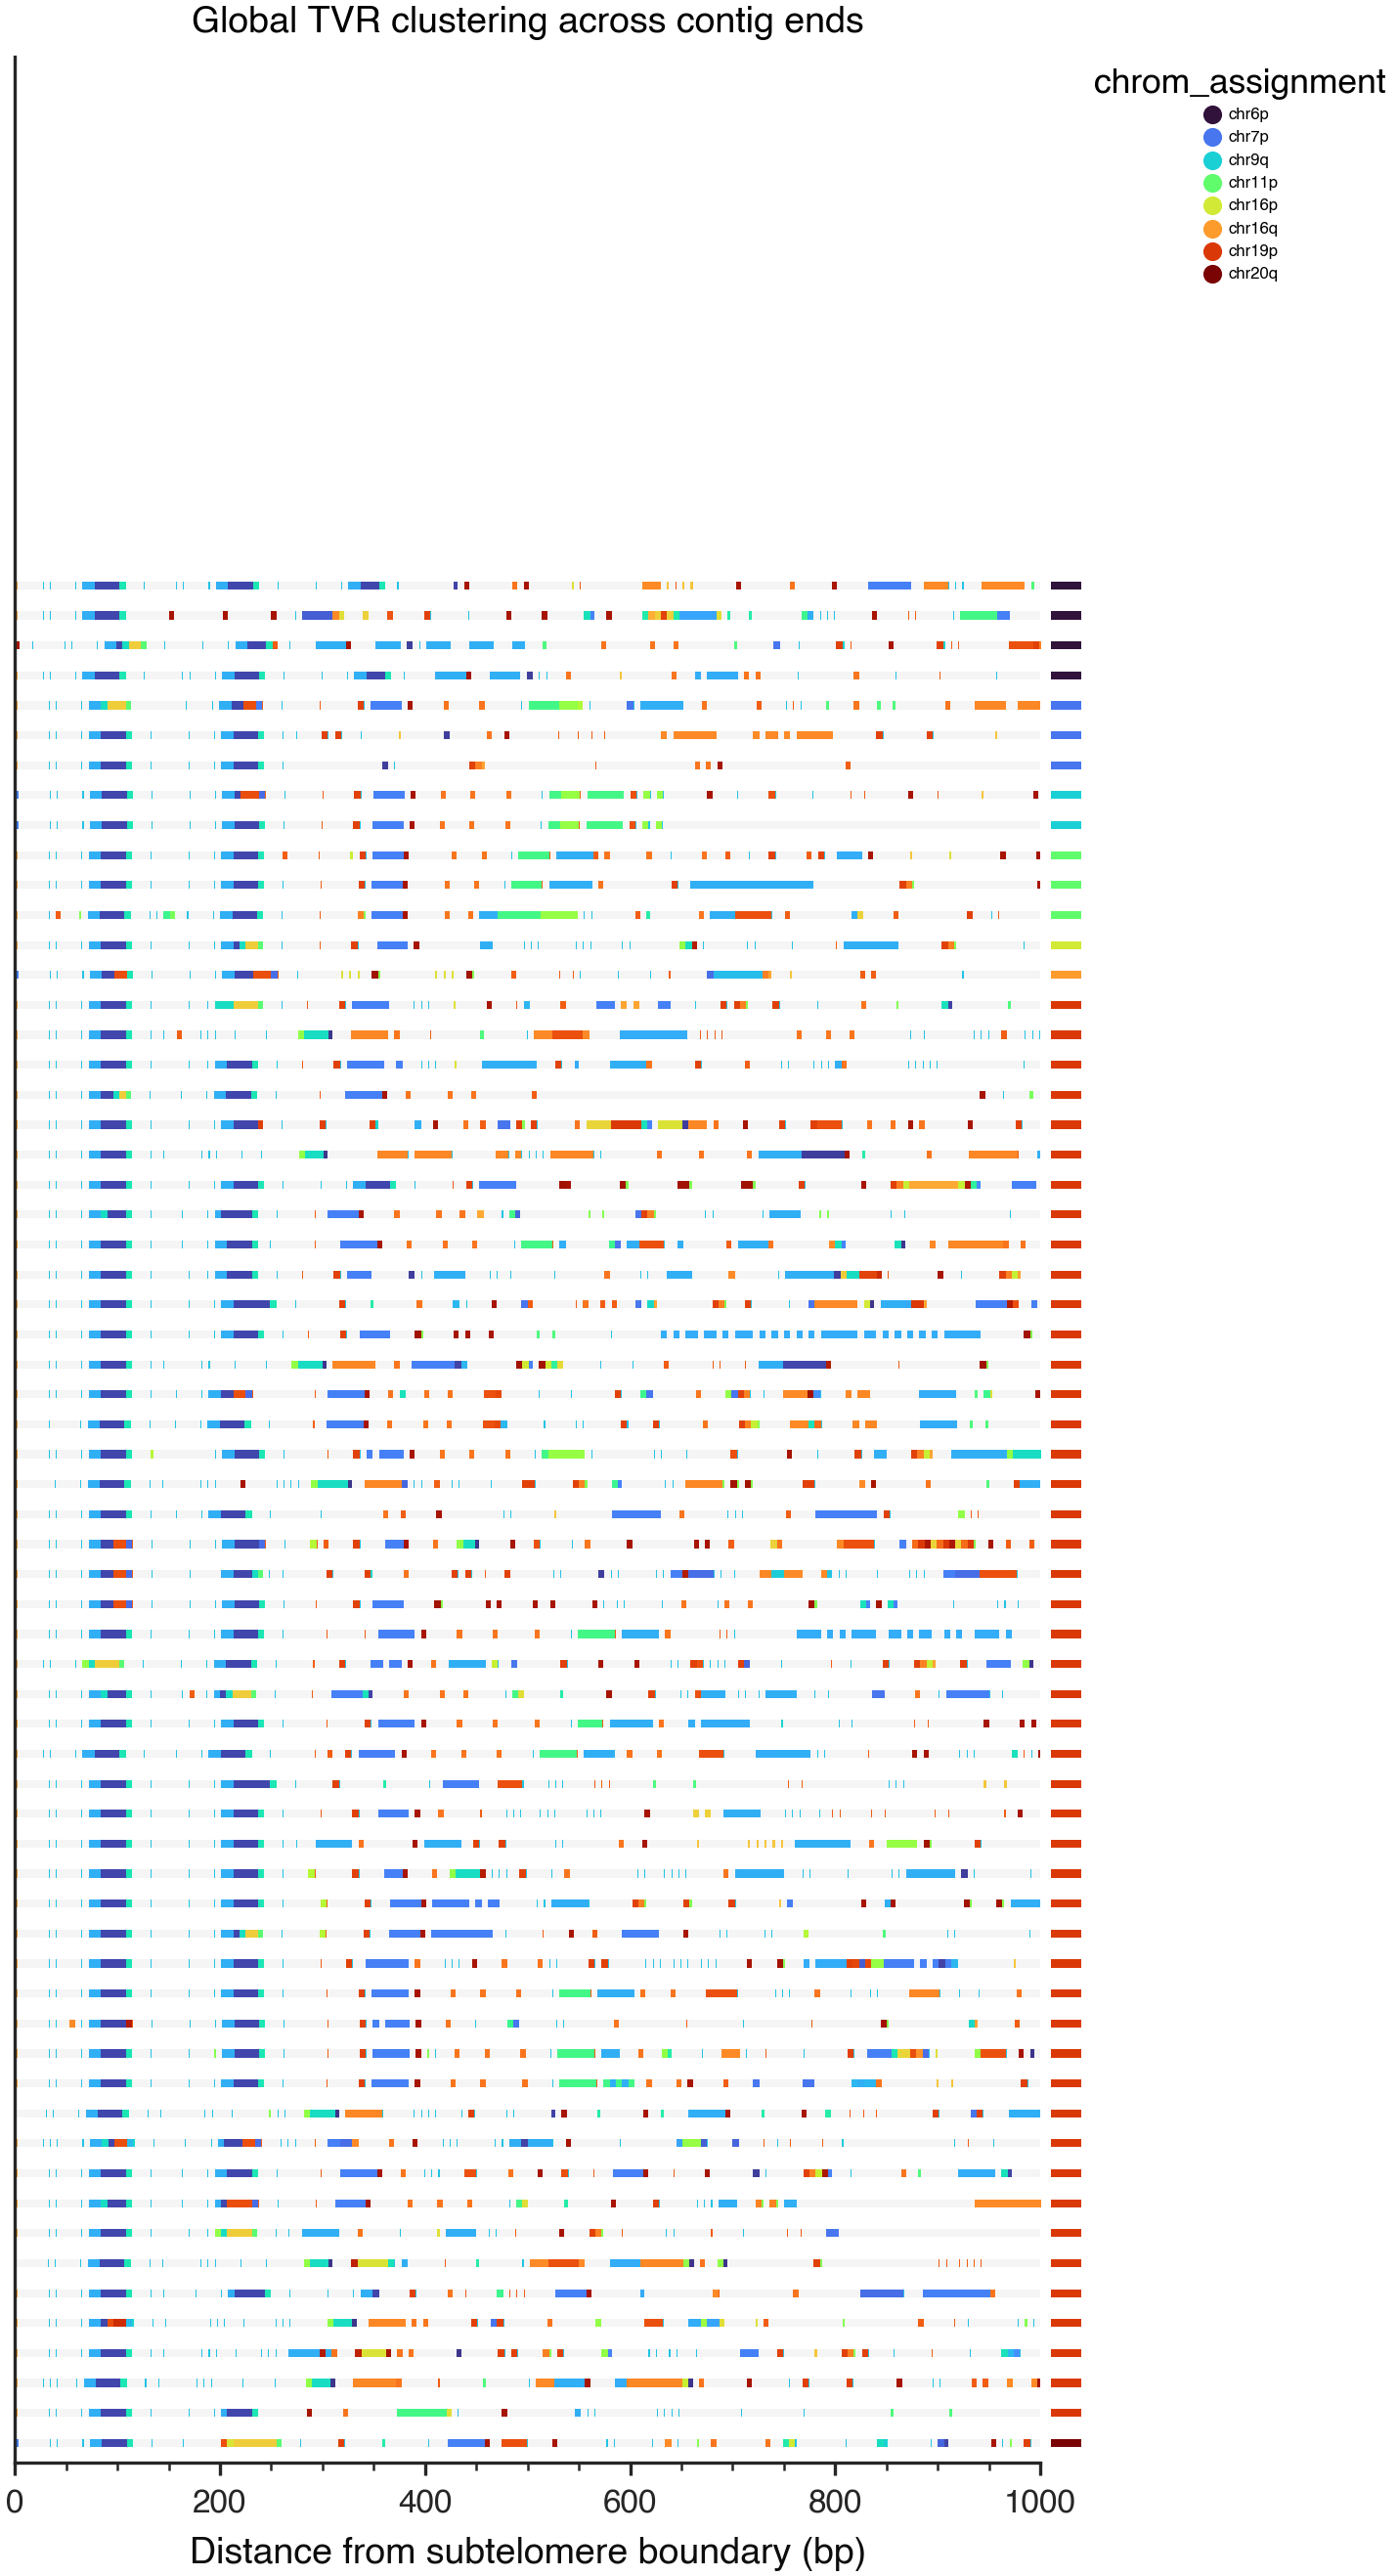

Plotting cluster 521 (n=59, mean_sim=0.774) -> None
MultiIndex([('chr16q', 'HG00344#2#CM094518.1', 'HG00344_2'),
            ('chr16q', 'HG00544#1#CM089378.1', 'HG00544_1'),
            ('chr16q', 'HG00544#2#CM089393.1', 'HG00544_2'),
            ('chr16q', 'HG00621#1#CM087858.1', 'HG00621_1'),
            ('chr16q', 'HG00642#1#CM086614.1', 'HG00642_1'),
            ('chr16q', 'HG00658#1#CM088783.1', 'HG00658_1'),
            ('chr16q', 'HG00658#2#CM088806.1', 'HG00658_2'),
            ('chr16q', 'HG02040#2#CM087412.1', 'HG02040_2'),
            ('chr16q', 'HG02056#1#CM085877.1', 'HG02056_1'),
            ('chr16q', 'HG02080#1#CM092068.1', 'HG02080_1'),
            ('chr16q', 'HG02132#1#CM086903.1', 'HG02132_1'),
            ('chr16q', 'HG02165#2#CM087466.1', 'HG02165_2'),
            ('chr16q', 'NA18570#2#CM087686.1', 'NA18570_2'),
            ('chr16q', 'NA18974#2#CM089803.1', 'NA18974_2'),
            ('chr16q', 'NA21093#1#CM089604.1', 'NA21093_1'),
            ('chr20p', 'HG01123#2

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 69.37it/s]


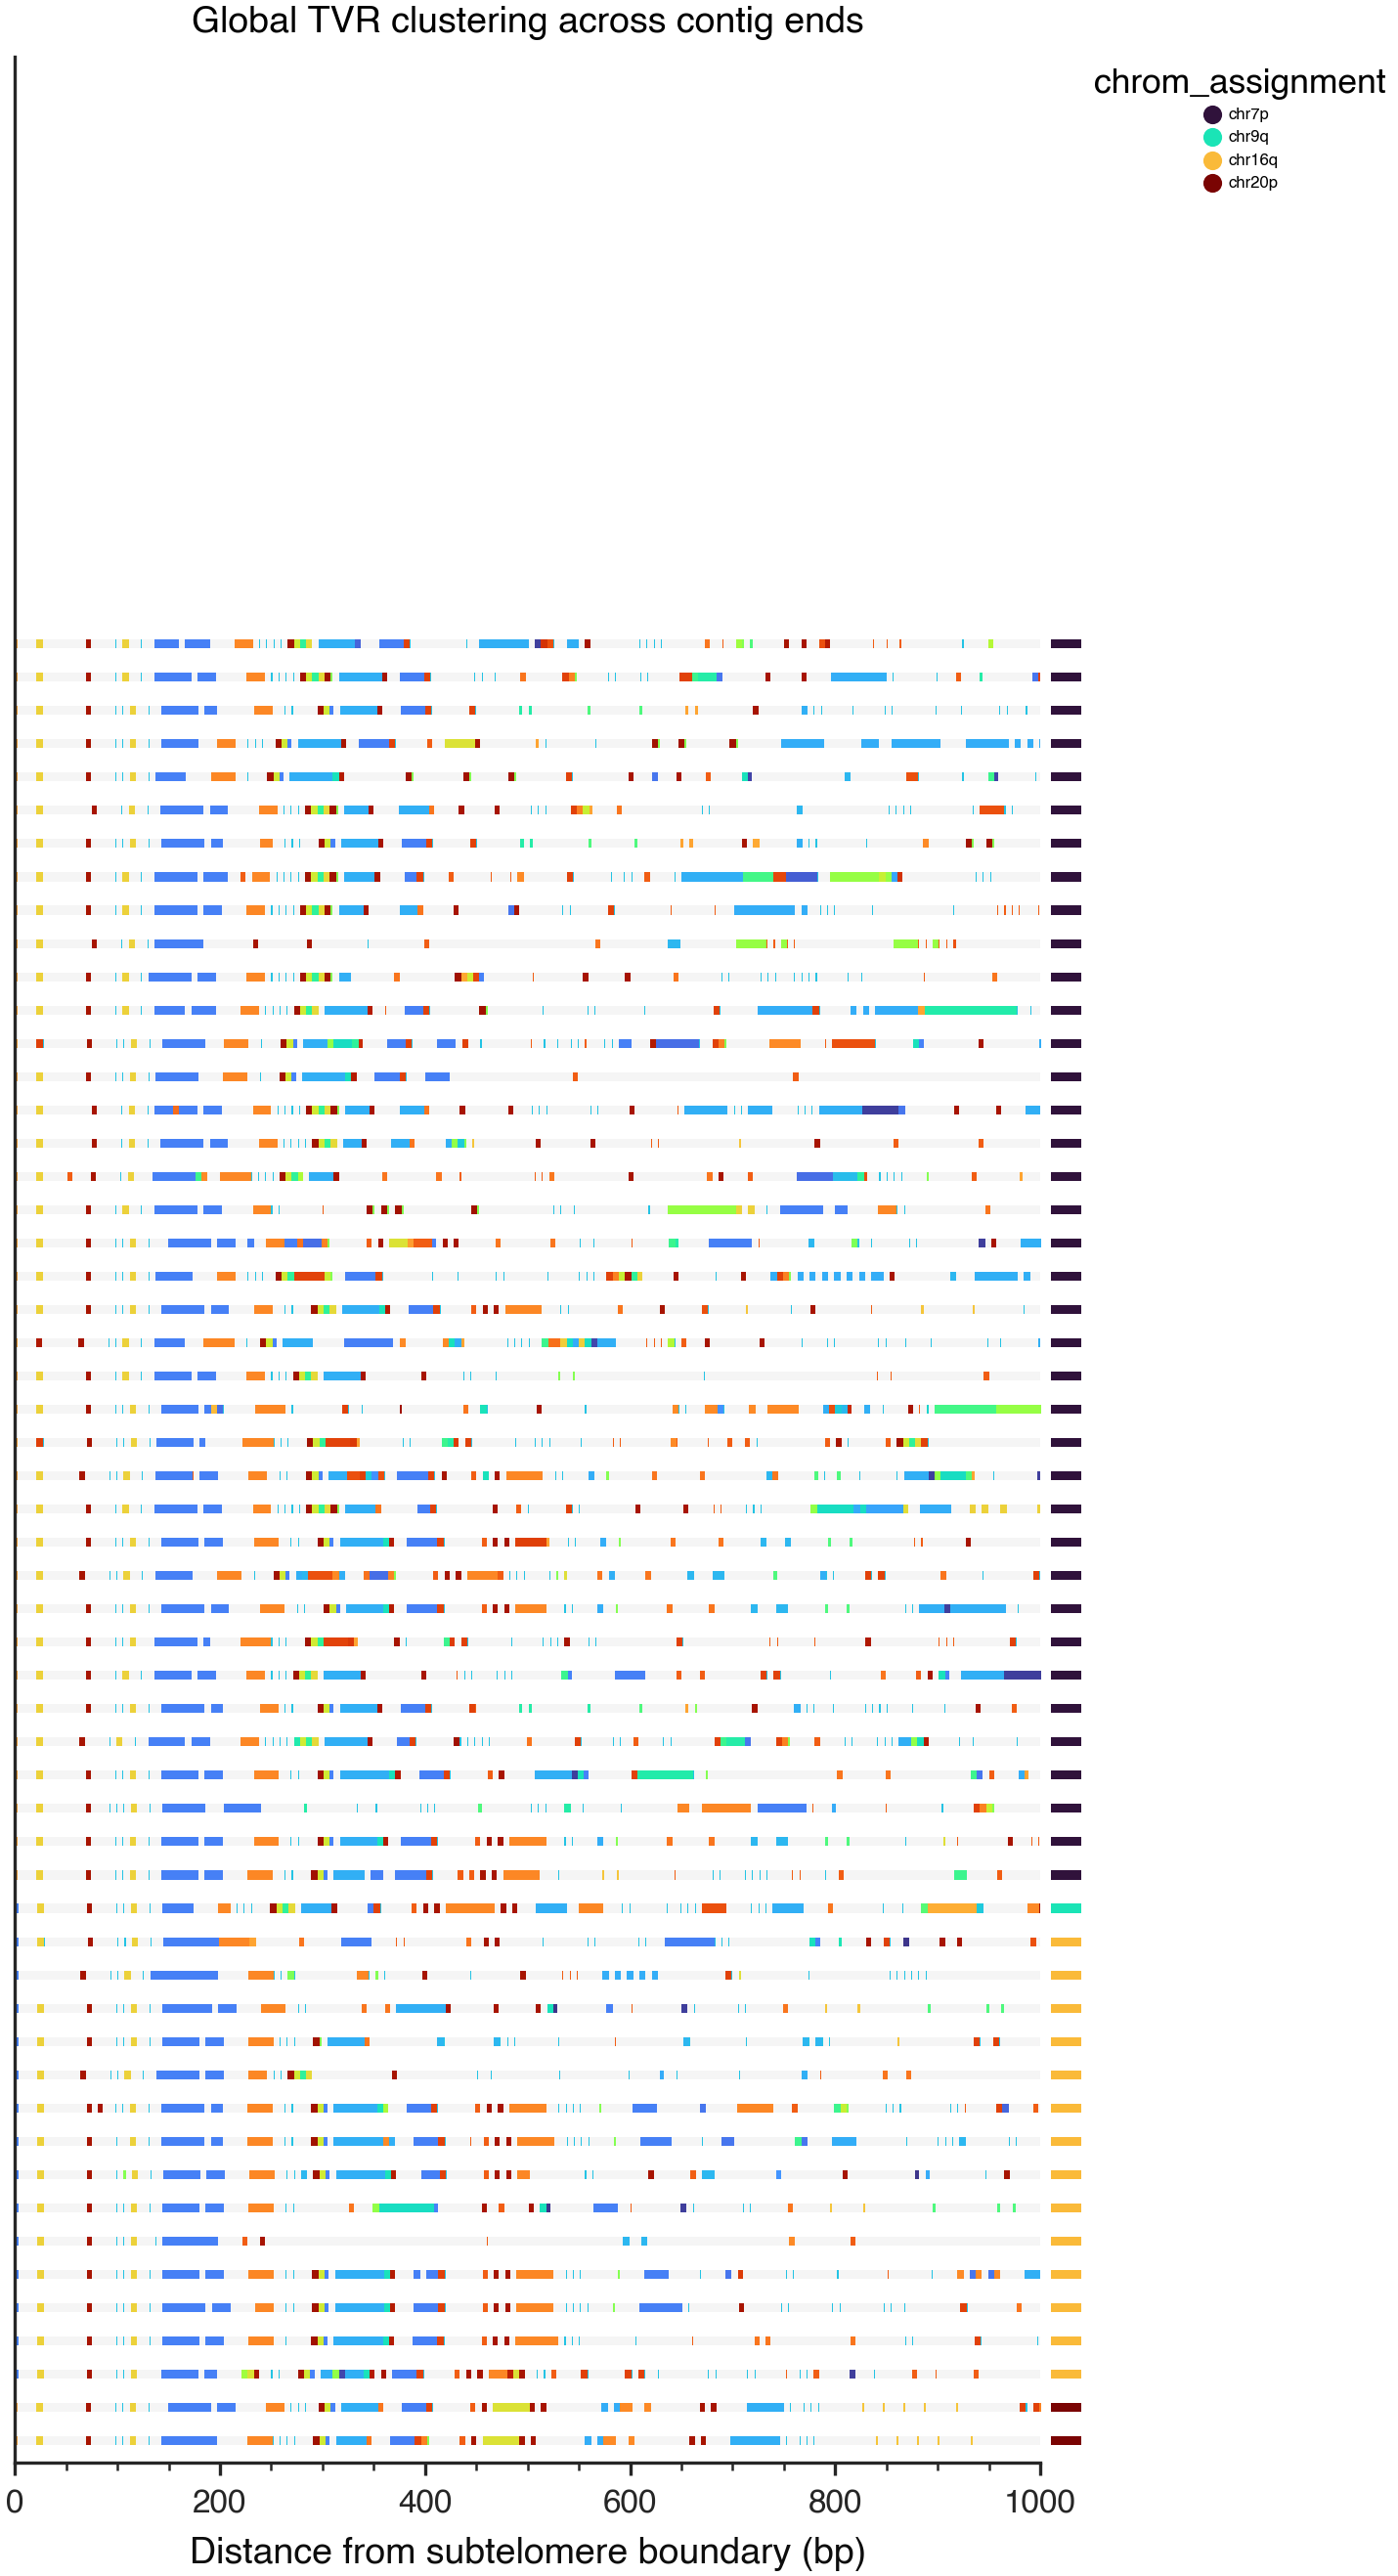

Plotting cluster 2209 (n=52, mean_sim=0.787) -> None
MultiIndex([('chr12p', 'HG00126#2#CM090130.1', 'HG00126_2'),
            ('chr12p', 'HG00128#2#CM090101.1', 'HG00128_2'),
            ('chr12p', 'HG00140#2#CM087142.1', 'HG00140_2'),
            ('chr12p', 'HG00253#1#CM094465.1', 'HG00253_1'),
            ('chr12p', 'HG00323#2#CM087336.1', 'HG00323_2'),
            ('chr12p', 'HG00642#2#CM086626.1', 'HG00642_2'),
            ('chr12p', 'HG00735#2#CM087893.1', 'HG00735_2'),
            ('chr12p', 'HG01258#1#CM088117.1', 'HG01258_1'),
            ('chr12p', 'HG01784#2#CM087603.1', 'HG01784_2'),
            ('chr12p', 'HG01928#1#CM088994.1', 'HG01928_1'),
            ('chr12p', 'HG01934#1#CM088846.1', 'HG01934_1'),
            ('chr12p', 'HG02300#1#CM086440.1', 'HG02300_1'),
            ('chr12p', 'HG03239#2#CM088767.1', 'HG03239_2'),
            ('chr12p', 'HG03927#1#CM086640.1', 'HG03927_1'),
            ('chr20q', 'HG00126#2#CM090134.1', 'HG00126_2'),
            ('chr20q', 'HG00232#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 69.85it/s]


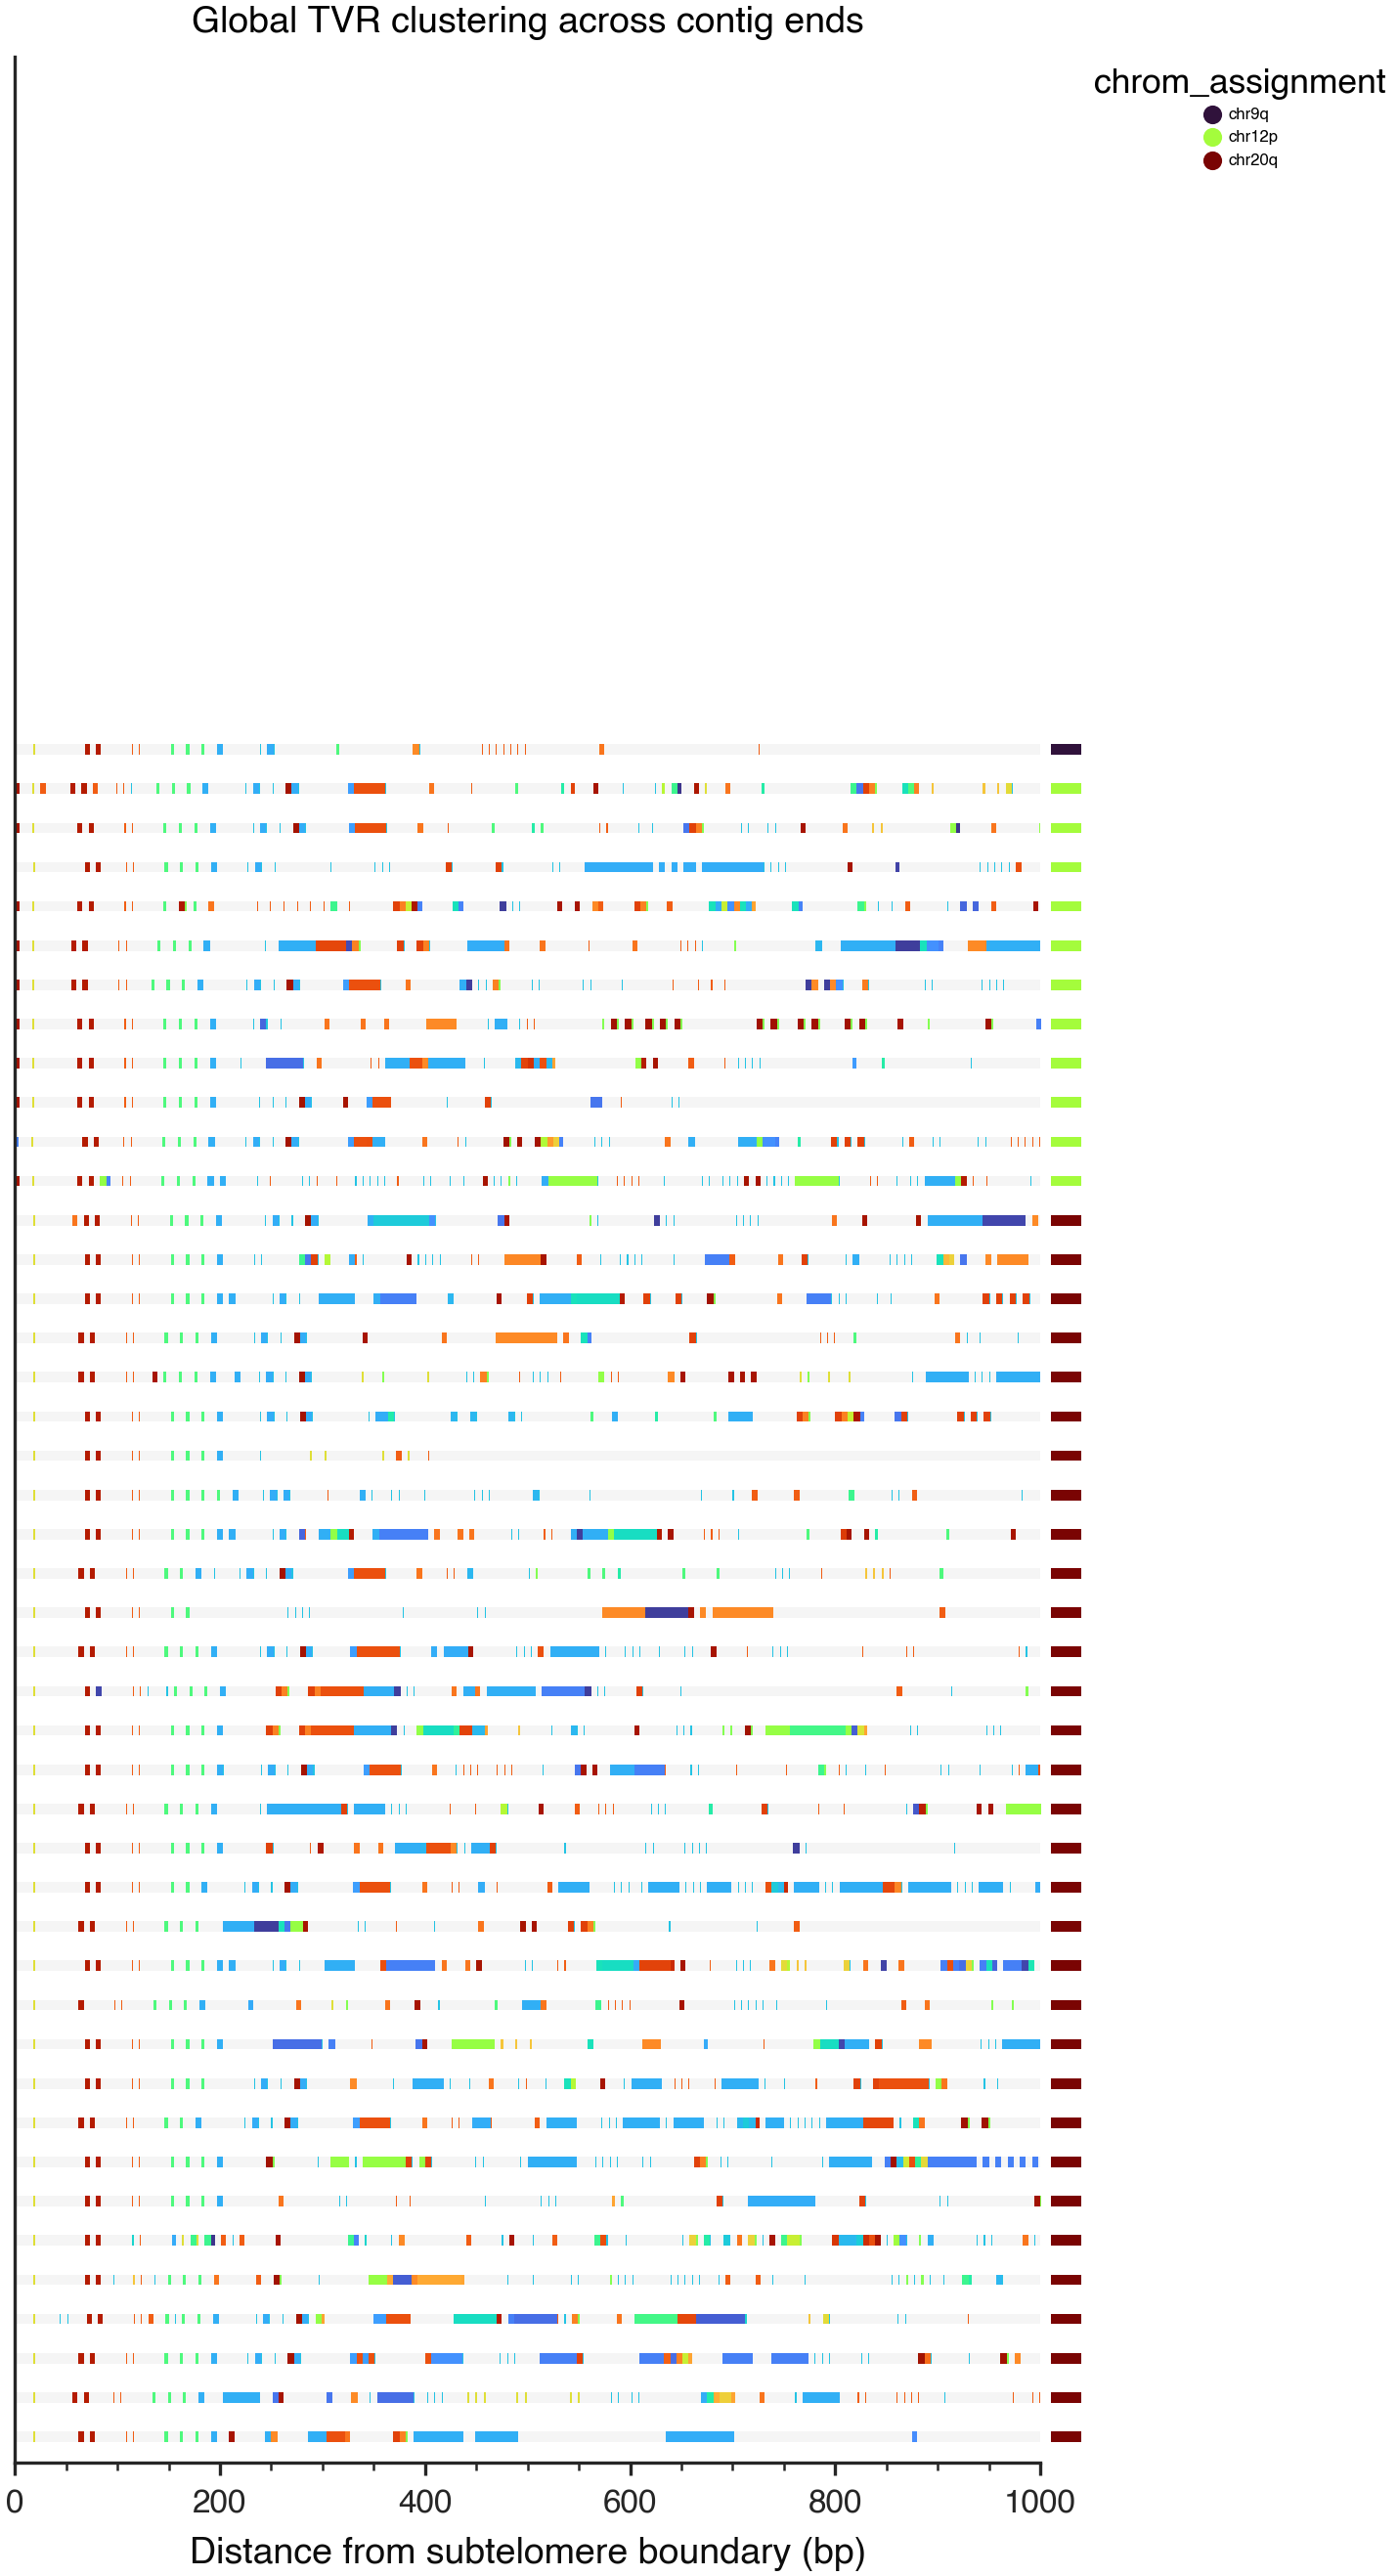

Plotting cluster 2655 (n=73, mean_sim=0.794) -> None
MultiIndex([('chr11p', 'HG03470#2#CM091875.1', 'HG03470_2'),
            ('chr15q', 'HG00321#1#CM089548.1', 'HG00321_1'),
            ('chr15q', 'HG00642#2#CM086629.1', 'HG00642_2'),
            ('chr15q', 'HG01940#1#CM088638.1', 'HG01940_1'),
            ('chr15q', 'HG02074#1#CM088276.1', 'HG02074_1'),
            ('chr15q', 'HG02155#1#CM091918.1', 'HG02155_1'),
            ('chr15q', 'HG02165#1#CM087450.1', 'HG02165_1'),
            ('chr15q', 'HG02922#1#CM087005.1', 'HG02922_1'),
            ('chr15q', 'NA18570#1#CM087667.1', 'NA18570_1'),
            ('chr15q', 'NA18570#2#CM087685.1', 'NA18570_2'),
            ('chr16p', 'HG02486#1#CM088201.1', 'HG02486_1'),
            ('chr16p', 'HG03209#1#CM087221.1', 'HG03209_1'),
            ('chr16q', 'HG01167#1#CM094534.1', 'HG01167_1'),
            ('chr16q', 'HG01891#2#CM088212.1', 'HG01891_2'),
            ('chr16q', 'HG01960#1#CM088652.1', 'HG01960_1'),
            ('chr16q', 'HG02486#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:01<00:00, 67.41it/s]


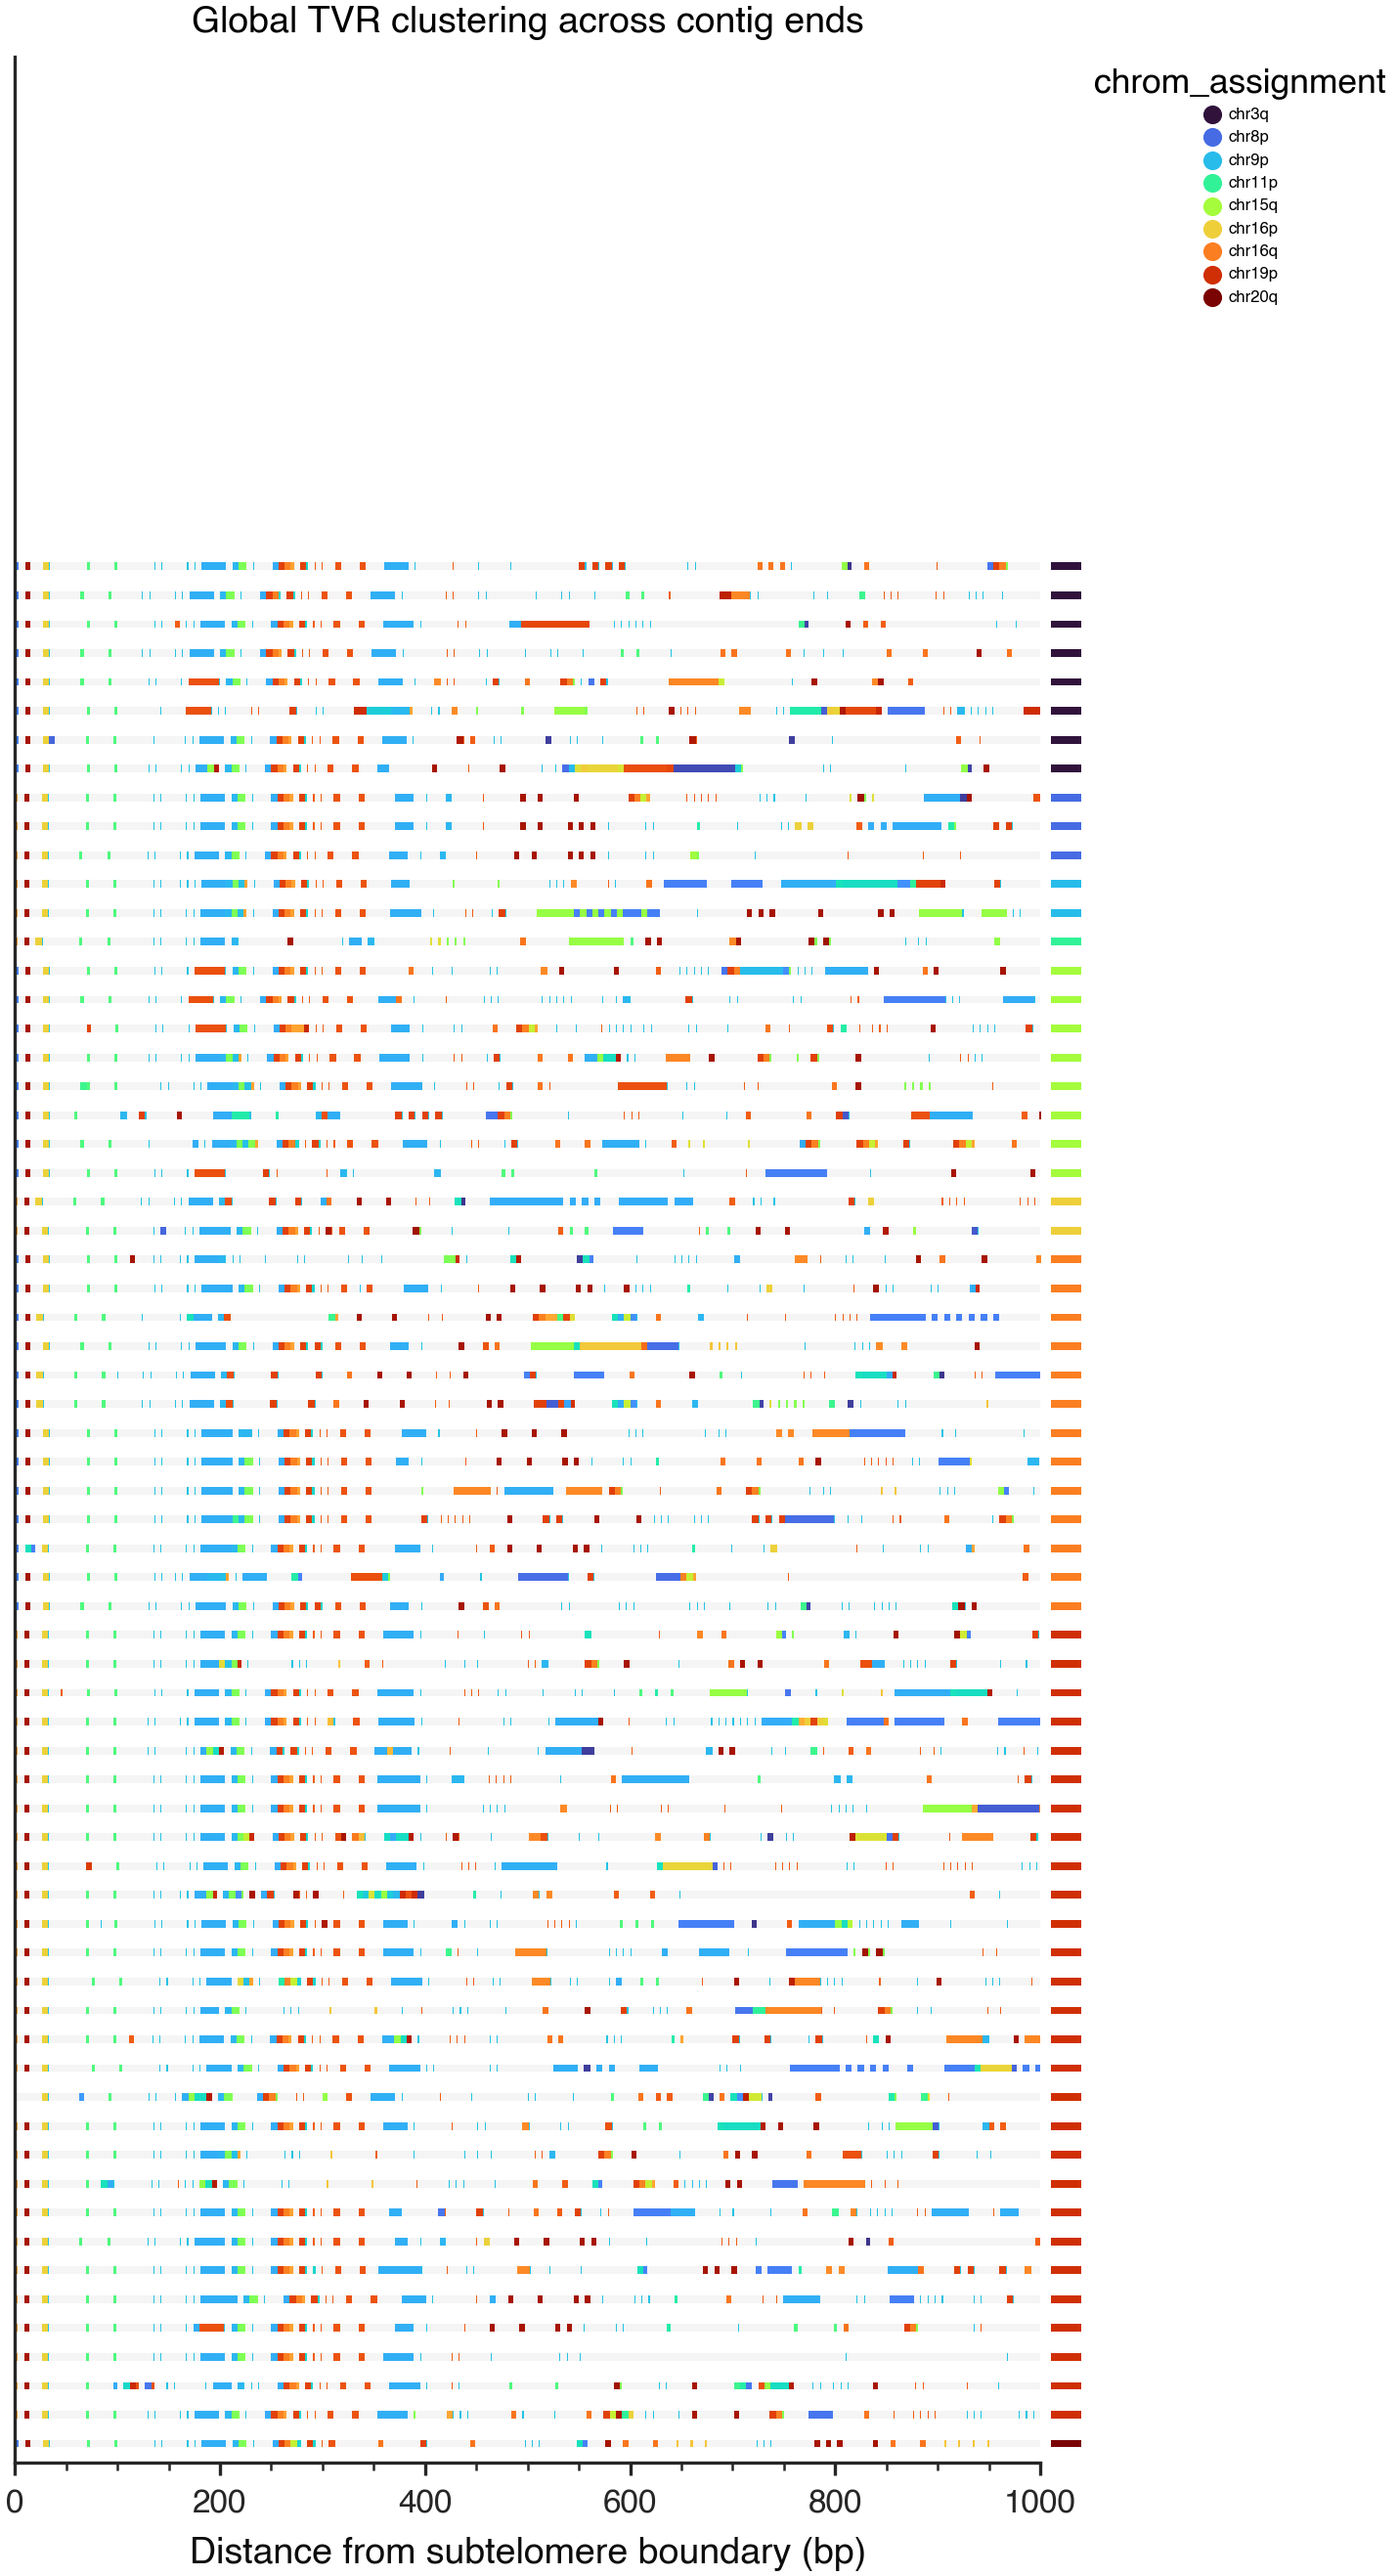

Plotting cluster 3486 (n=58, mean_sim=0.742) -> None
MultiIndex([('chr4p', 'HG00133#1#CM090048.1', 'HG00133_1'),
            ('chr4p', 'HG00438#1#CM089170.1', 'HG00438_1'),
            ('chr4p', 'HG00438#2#CM089189.1', 'HG00438_2'),
            ('chr4p', 'HG00609#1#CM086349.1', 'HG00609_1'),
            ('chr4p', 'HG00609#2#CM086359.1', 'HG00609_2'),
            ('chr4p', 'HG00621#1#CM087849.1', 'HG00621_1'),
            ('chr4p', 'HG00639#1#CM088538.1', 'HG00639_1'),
            ('chr4p', 'HG00642#2#CM086620.1', 'HG00642_2'),
            ('chr4p', 'HG00706#2#CM100058.1', 'HG00706_2'),
            ('chr4p', 'HG00735#2#CM087886.1', 'HG00735_2'),
            ('chr4p', 'HG01071#2#CM089130.1', 'HG01071_2'),
            ('chr4p', 'HG01175#2#CM087938.1', 'HG01175_2'),
            ('chr4p', 'HG01258#1#CM088111.1', 'HG01258_1'),
            ('chr4p', 'HG01346#2#CM086599.1', 'HG01346_2'),
            ('chr4p', 'HG01361#1#CM089022.1', 'HG01361_1'),
            ('chr4p', 'HG01433#2#CM086509.1', '

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 68.61it/s]


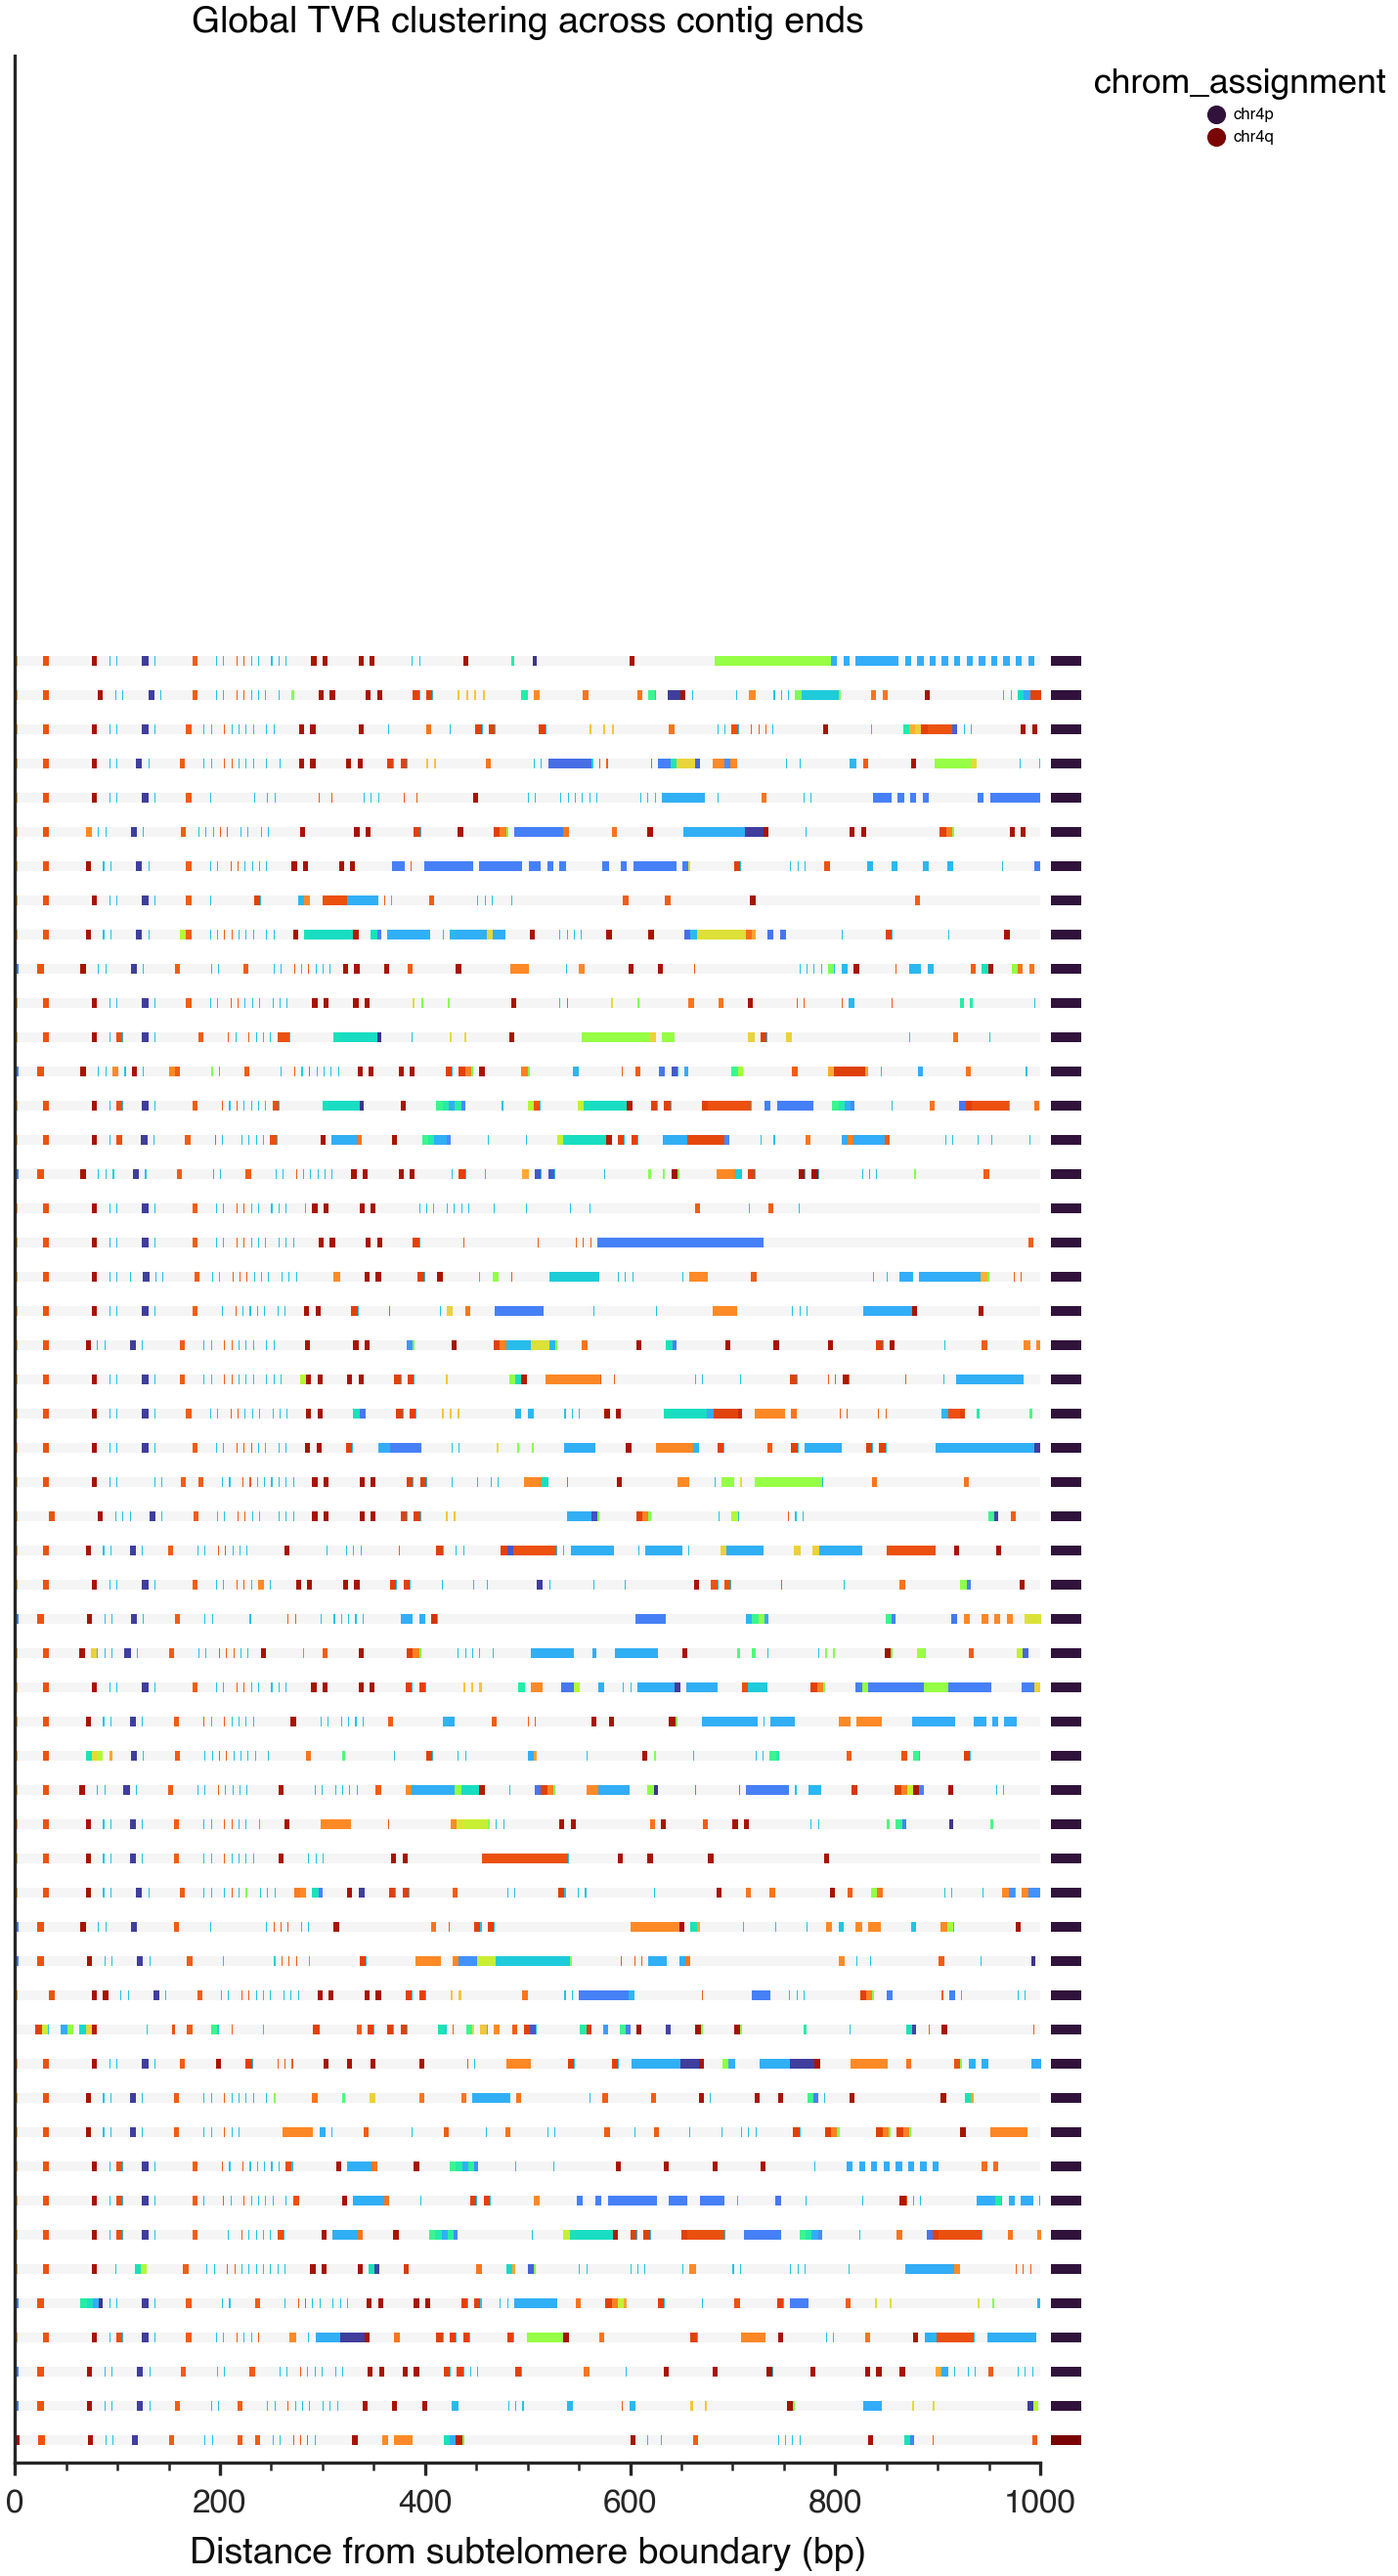

Plotting cluster 3680 (n=74, mean_sim=0.757) -> None
MultiIndex([('chr2q', 'HG03017#1#CM088909.1', 'HG03017_1'),
            ('chr2q', 'HG03816#1#CM100025.1', 'HG03816_1'),
            ('chr2q', 'NA20870#2#CM089709.1', 'NA20870_2'),
            ('chr5q', 'HG00097#1#CM094063.1', 'HG00097_1'),
            ('chr5q', 'HG00099#2#CM087360.1', 'HG00099_2'),
            ('chr5q', 'HG00133#2#CM090064.1', 'HG00133_2'),
            ('chr5q', 'HG00235#1#CM094372.1', 'HG00235_1'),
            ('chr5q', 'HG00320#2#CM089964.1', 'HG00320_2'),
            ('chr5q', 'HG00323#1#CM087305.1', 'HG00323_1'),
            ('chr5q', 'HG00344#2#CM094515.1', 'HG00344_2'),
            ('chr5q', 'HG00350#1#CM094471.1', 'HG00350_1'),
            ('chr5q', 'HG00408#2#CM085968.1', 'HG00408_2'),
            ('chr5q', 'HG00438#1#CM089171.1', 'HG00438_1'),
            ('chr5q', 'HG00544#1#CM089372.1', 'HG00544_1'),
            ('chr5q', 'HG00621#1#CM087850.1', 'HG00621_1'),
            ('chr5q', 'HG00621#2#CM087864.1', '

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74/74 [00:01<00:00, 70.71it/s]


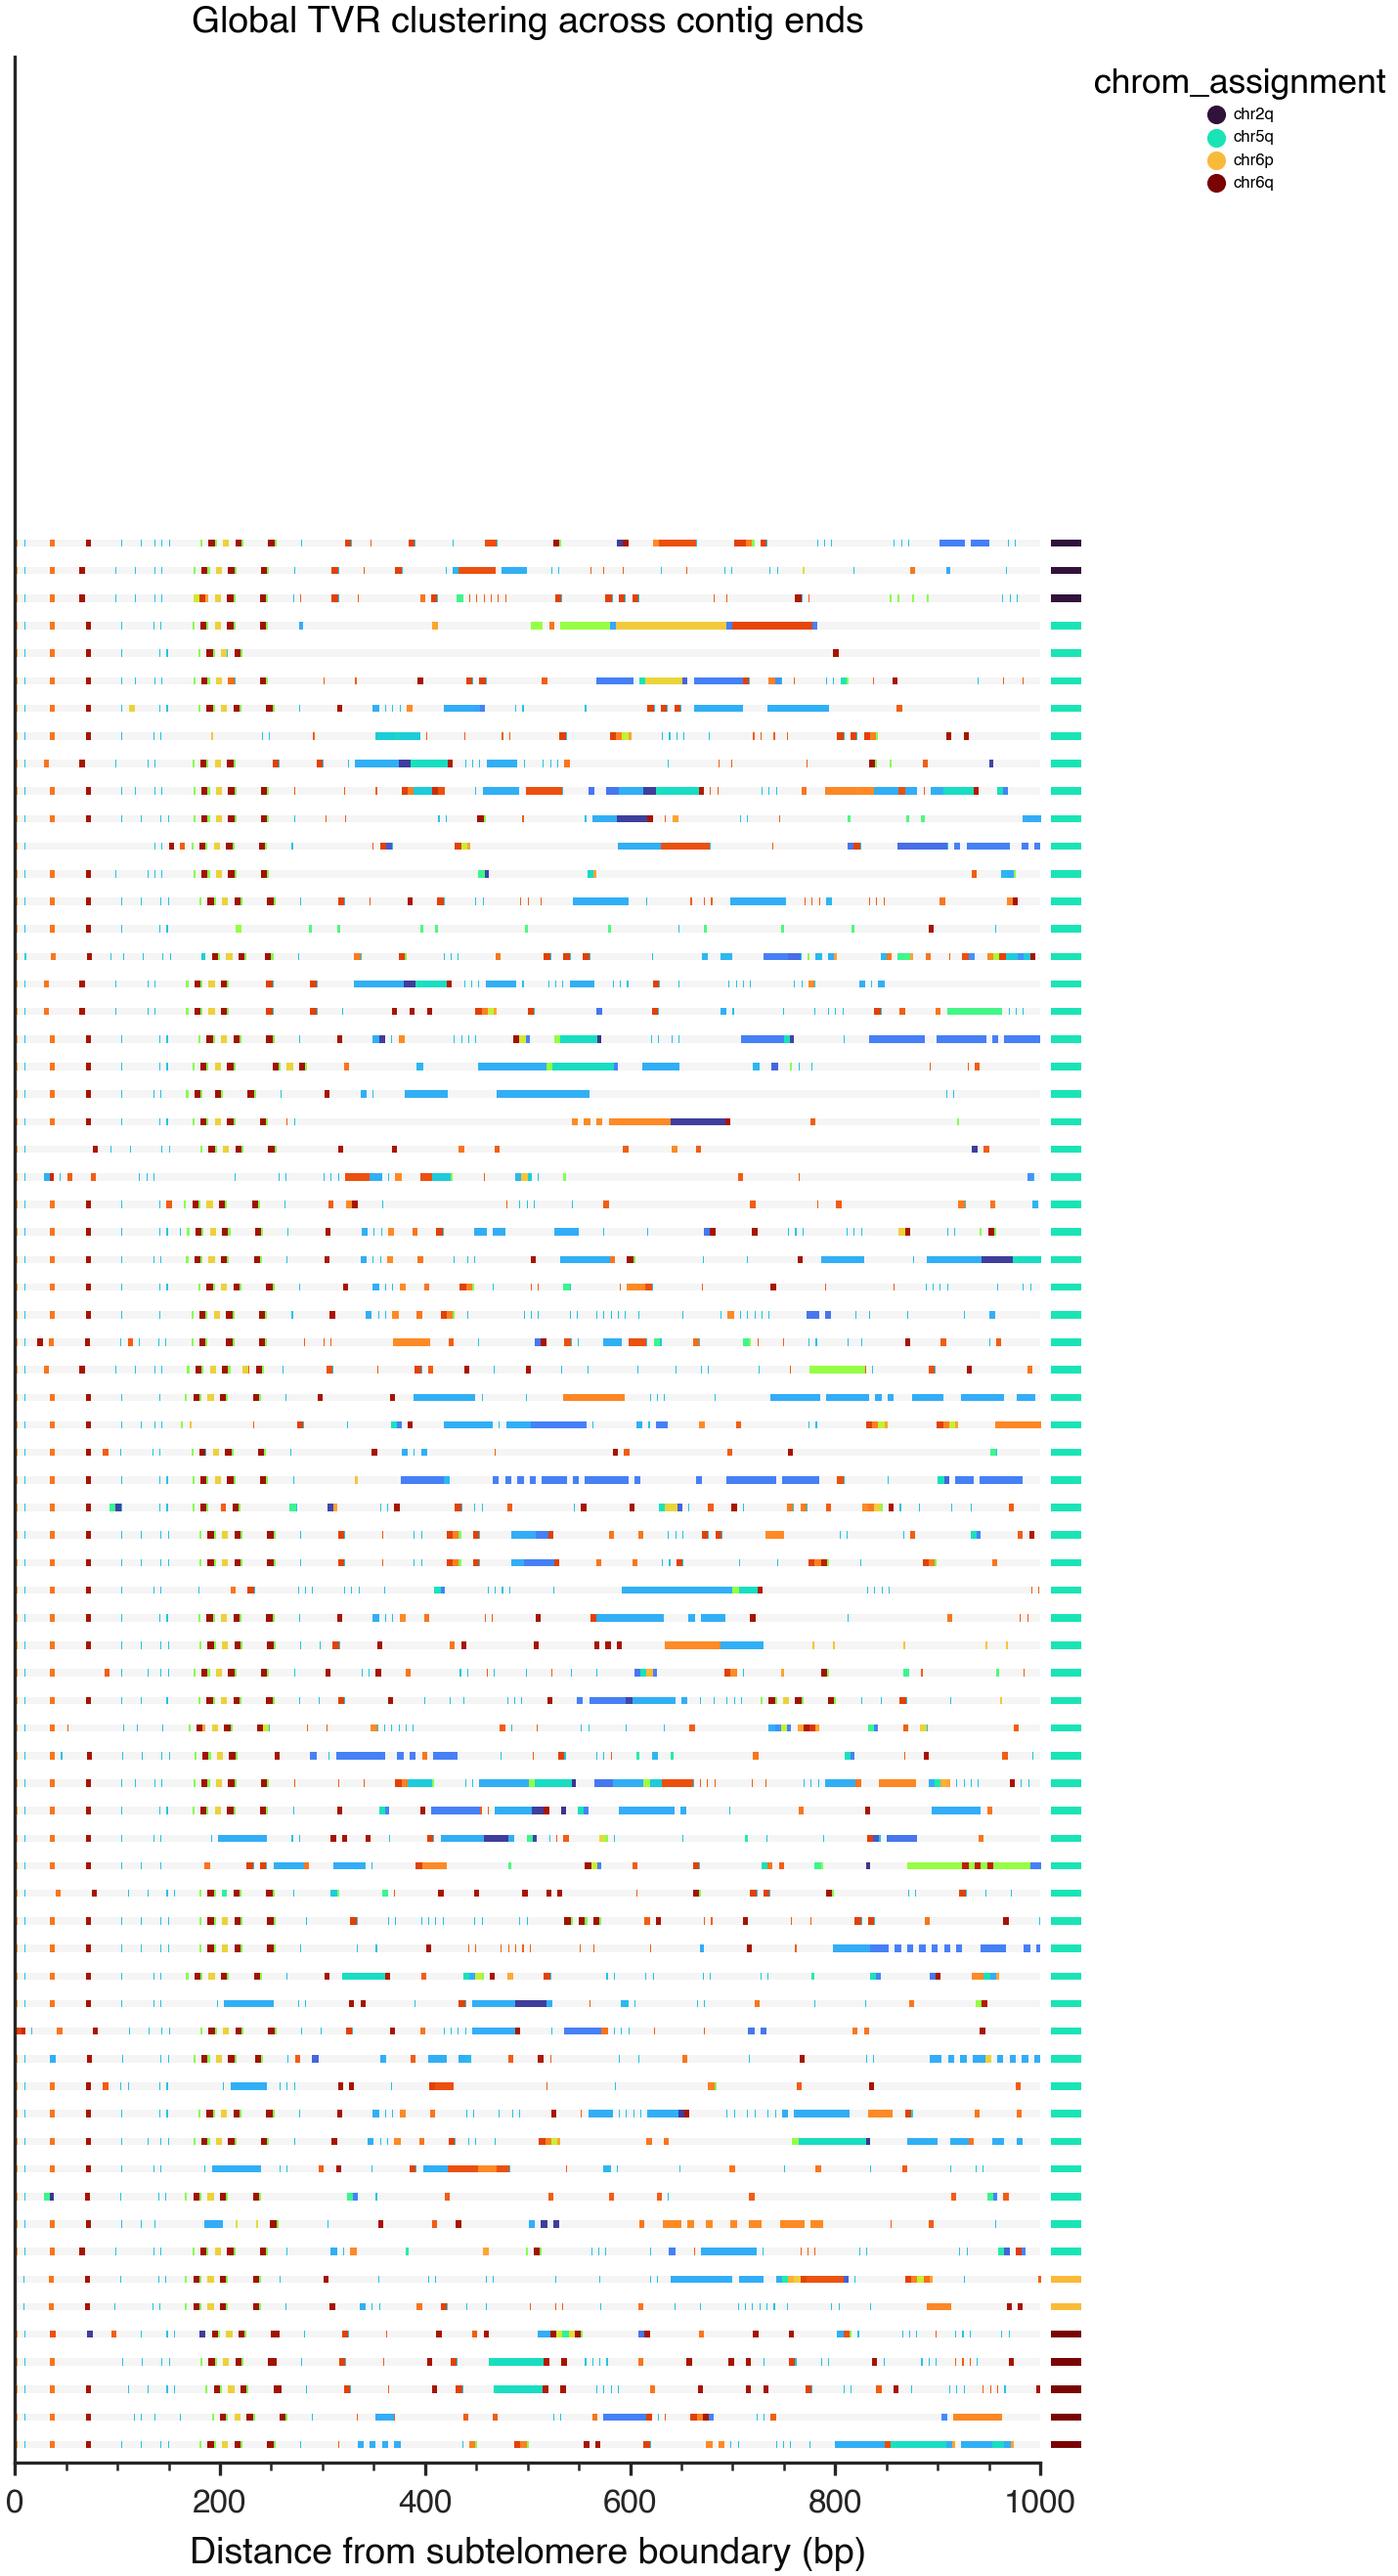

In [26]:

from matplotlib import cm, colors as mcolors
from scipy.cluster.hierarchy import leaves_list



# main figures plot a randomly sampled molecule per individual
plot_significant_tvr_clusters(
    big_tsv=hprc_tsv_total_filtered,
    linkage_matrix=linkage_matrix,
    labels=labels,
    similarity_matrix=M,
    sim_threshold=0.7,
    min_contigs=50,
    dist_bp=1000,
    figsize=(5, 9),
    cmgr=cmgr,
    min_reads_per_group=5,
    min_tvr_size=1,
    max_tvr_size=300,
    flip=True,
    max_mols_per_group=1,
    out_prefix=None   
)

Found 6 significant clusters.
  - cluster 316: n=68, mean similarity=0.801
  - cluster 521: n=59, mean similarity=0.774
  - cluster 2209: n=52, mean similarity=0.787
  - cluster 2655: n=73, mean similarity=0.794
  - cluster 3486: n=58, mean similarity=0.742
  - cluster 3680: n=74, mean similarity=0.757
Plotting cluster 316 (n=68, mean_sim=0.801) -> None
MultiIndex([('chr11p', 'HG03050#1#CM098768.1', 'HG03050_1'),
            ('chr11p', 'HG03139#2#CM091842.1', 'HG03139_2'),
            ('chr11p', 'HG03225#1#CM089305.1', 'HG03225_1'),
            ('chr16p', 'NA19835#1#CM094029.1', 'NA19835_1'),
            ('chr16q', 'HG03098#1#CM092238.1', 'HG03098_1'),
            ('chr19p', 'HG00099#1#CM087326.1', 'HG00099_1'),
            ('chr19p', 'HG00099#2#CM087370.1', 'HG00099_2'),
            ('chr19p', 'HG00140#1#CM087120.1', 'HG00140_1'),
            ('chr19p', 'HG00253#1#CM094466.1', 'HG00253_1'),
            ('chr19p', 'HG00272#2#CM094225.1', 'HG00272_2'),
            ('chr19p', 'HG00423#2#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:02<00:00, 22.82it/s]


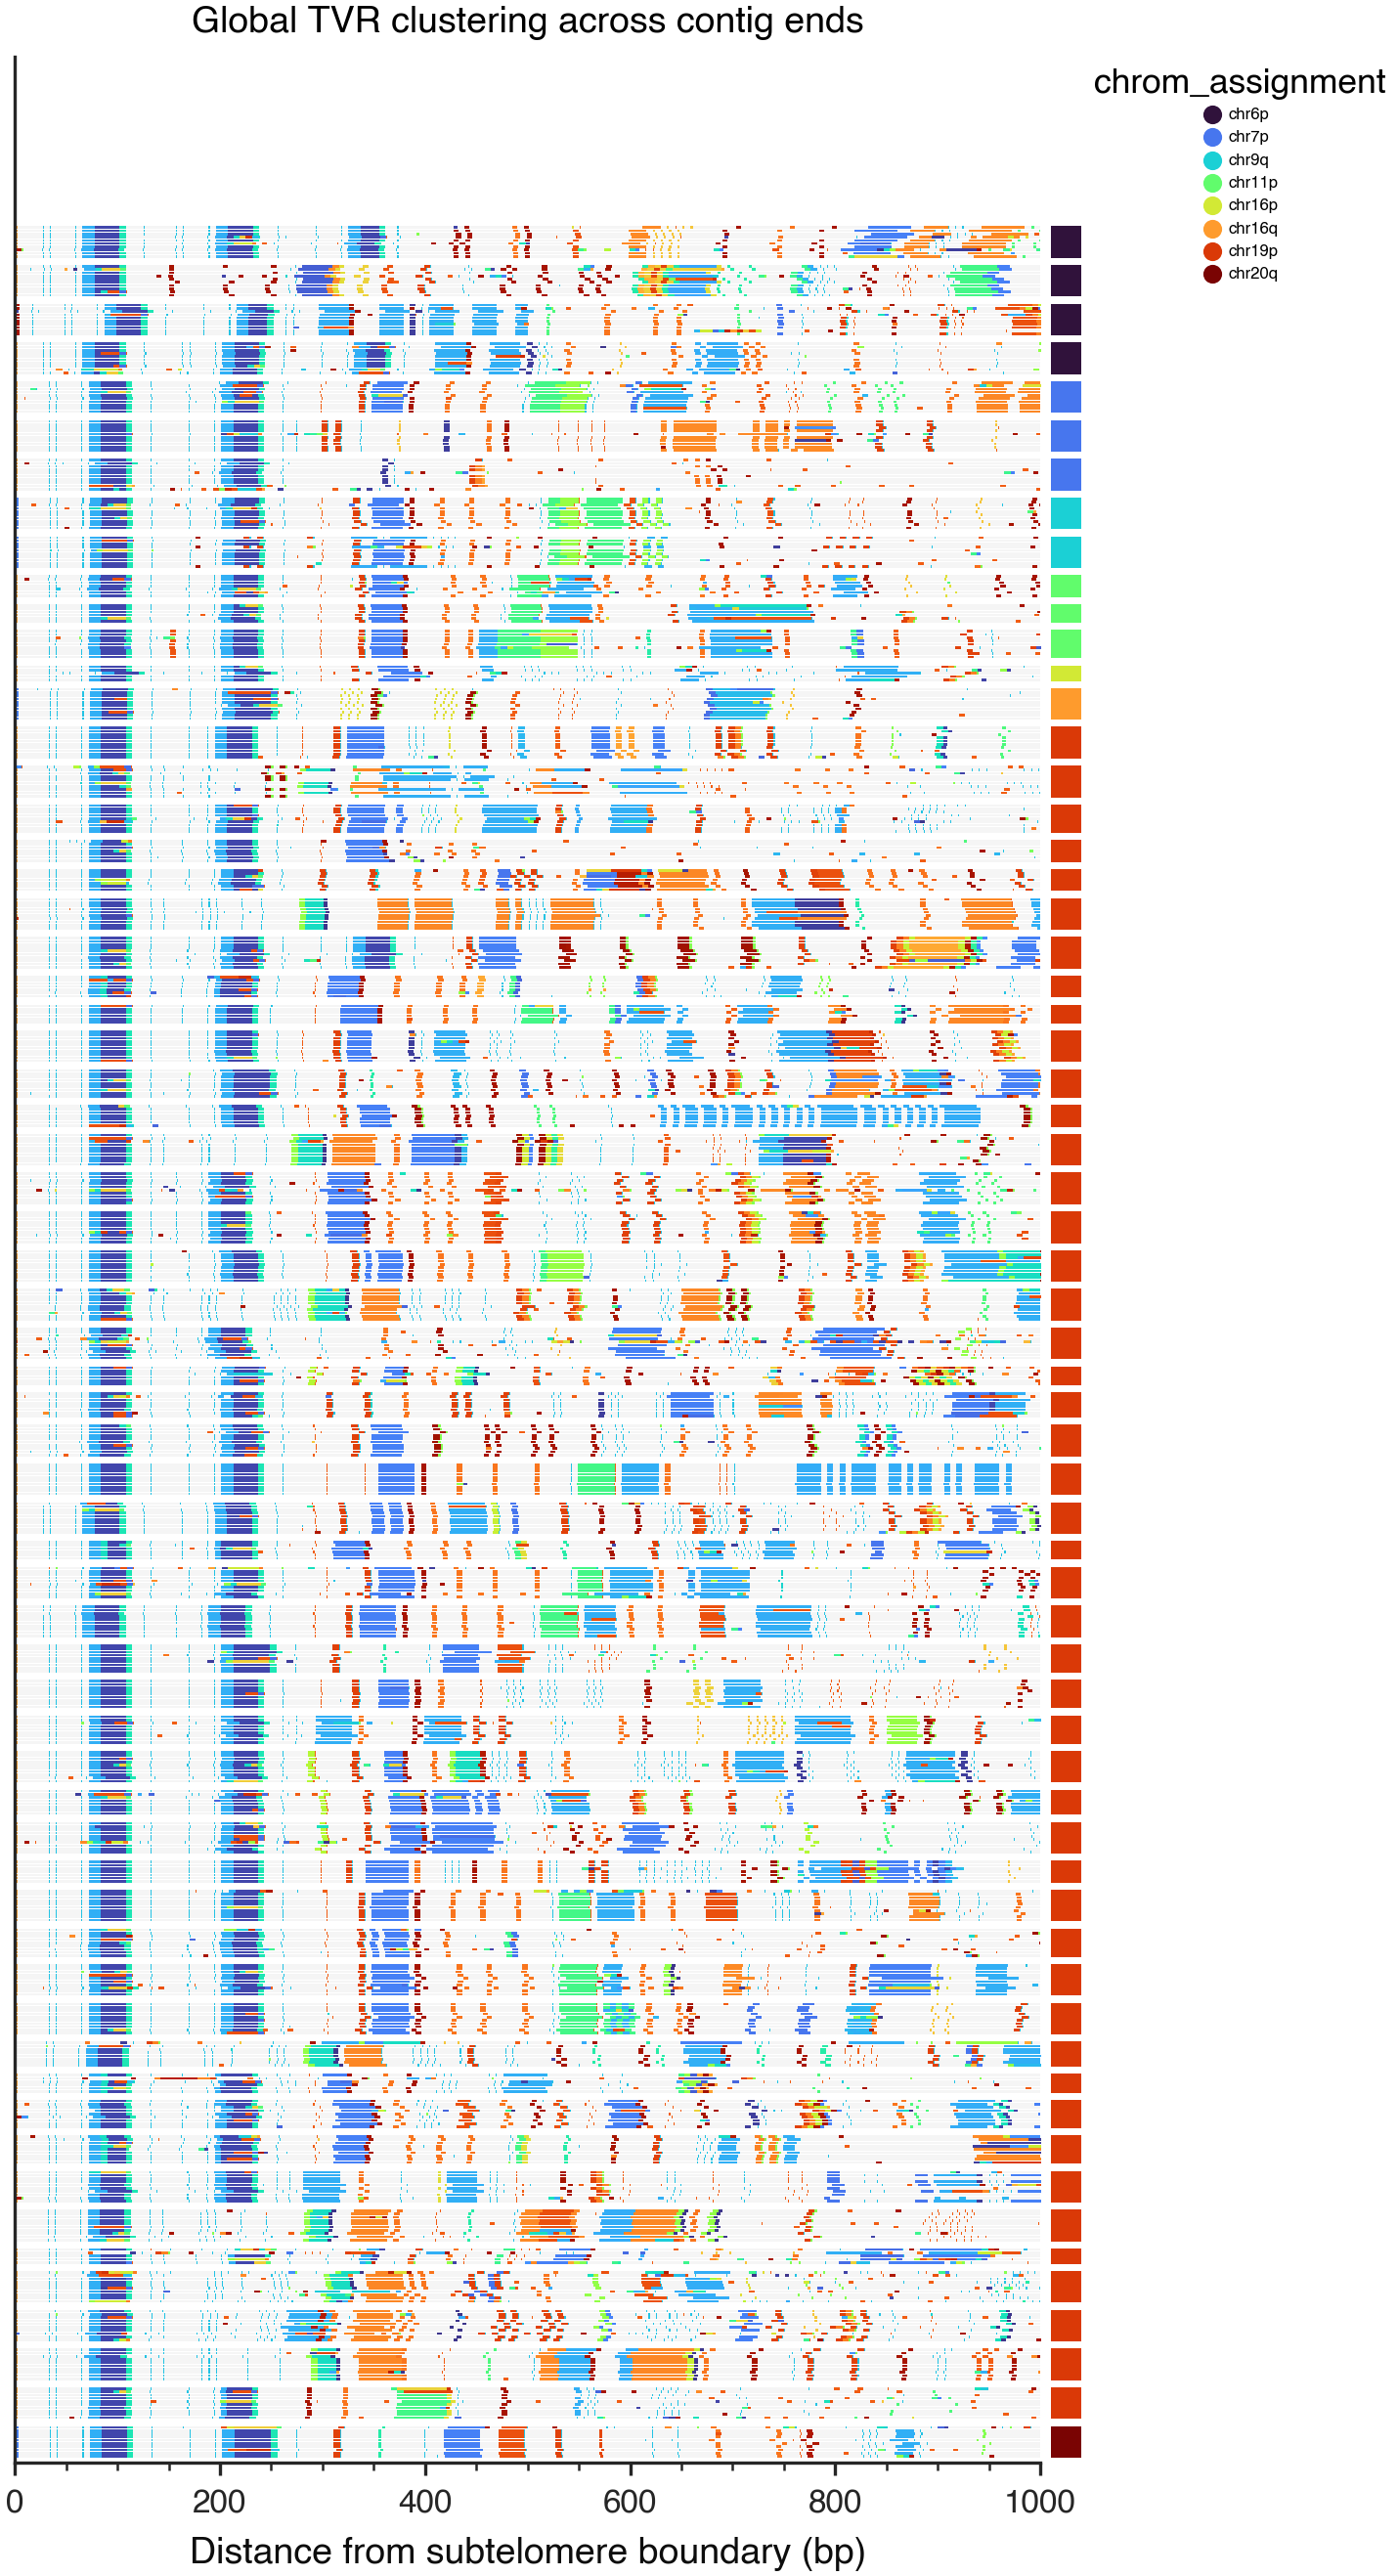

Plotting cluster 521 (n=59, mean_sim=0.774) -> None
MultiIndex([('chr16q', 'HG00344#2#CM094518.1', 'HG00344_2'),
            ('chr16q', 'HG00544#1#CM089378.1', 'HG00544_1'),
            ('chr16q', 'HG00544#2#CM089393.1', 'HG00544_2'),
            ('chr16q', 'HG00621#1#CM087858.1', 'HG00621_1'),
            ('chr16q', 'HG00642#1#CM086614.1', 'HG00642_1'),
            ('chr16q', 'HG00658#1#CM088783.1', 'HG00658_1'),
            ('chr16q', 'HG00658#2#CM088806.1', 'HG00658_2'),
            ('chr16q', 'HG02040#2#CM087412.1', 'HG02040_2'),
            ('chr16q', 'HG02056#1#CM085877.1', 'HG02056_1'),
            ('chr16q', 'HG02080#1#CM092068.1', 'HG02080_1'),
            ('chr16q', 'HG02132#1#CM086903.1', 'HG02132_1'),
            ('chr16q', 'HG02165#2#CM087466.1', 'HG02165_2'),
            ('chr16q', 'NA18570#2#CM087686.1', 'NA18570_2'),
            ('chr16q', 'NA18974#2#CM089803.1', 'NA18974_2'),
            ('chr16q', 'NA21093#1#CM089604.1', 'NA21093_1'),
            ('chr20p', 'HG01123#2

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 20.56it/s]


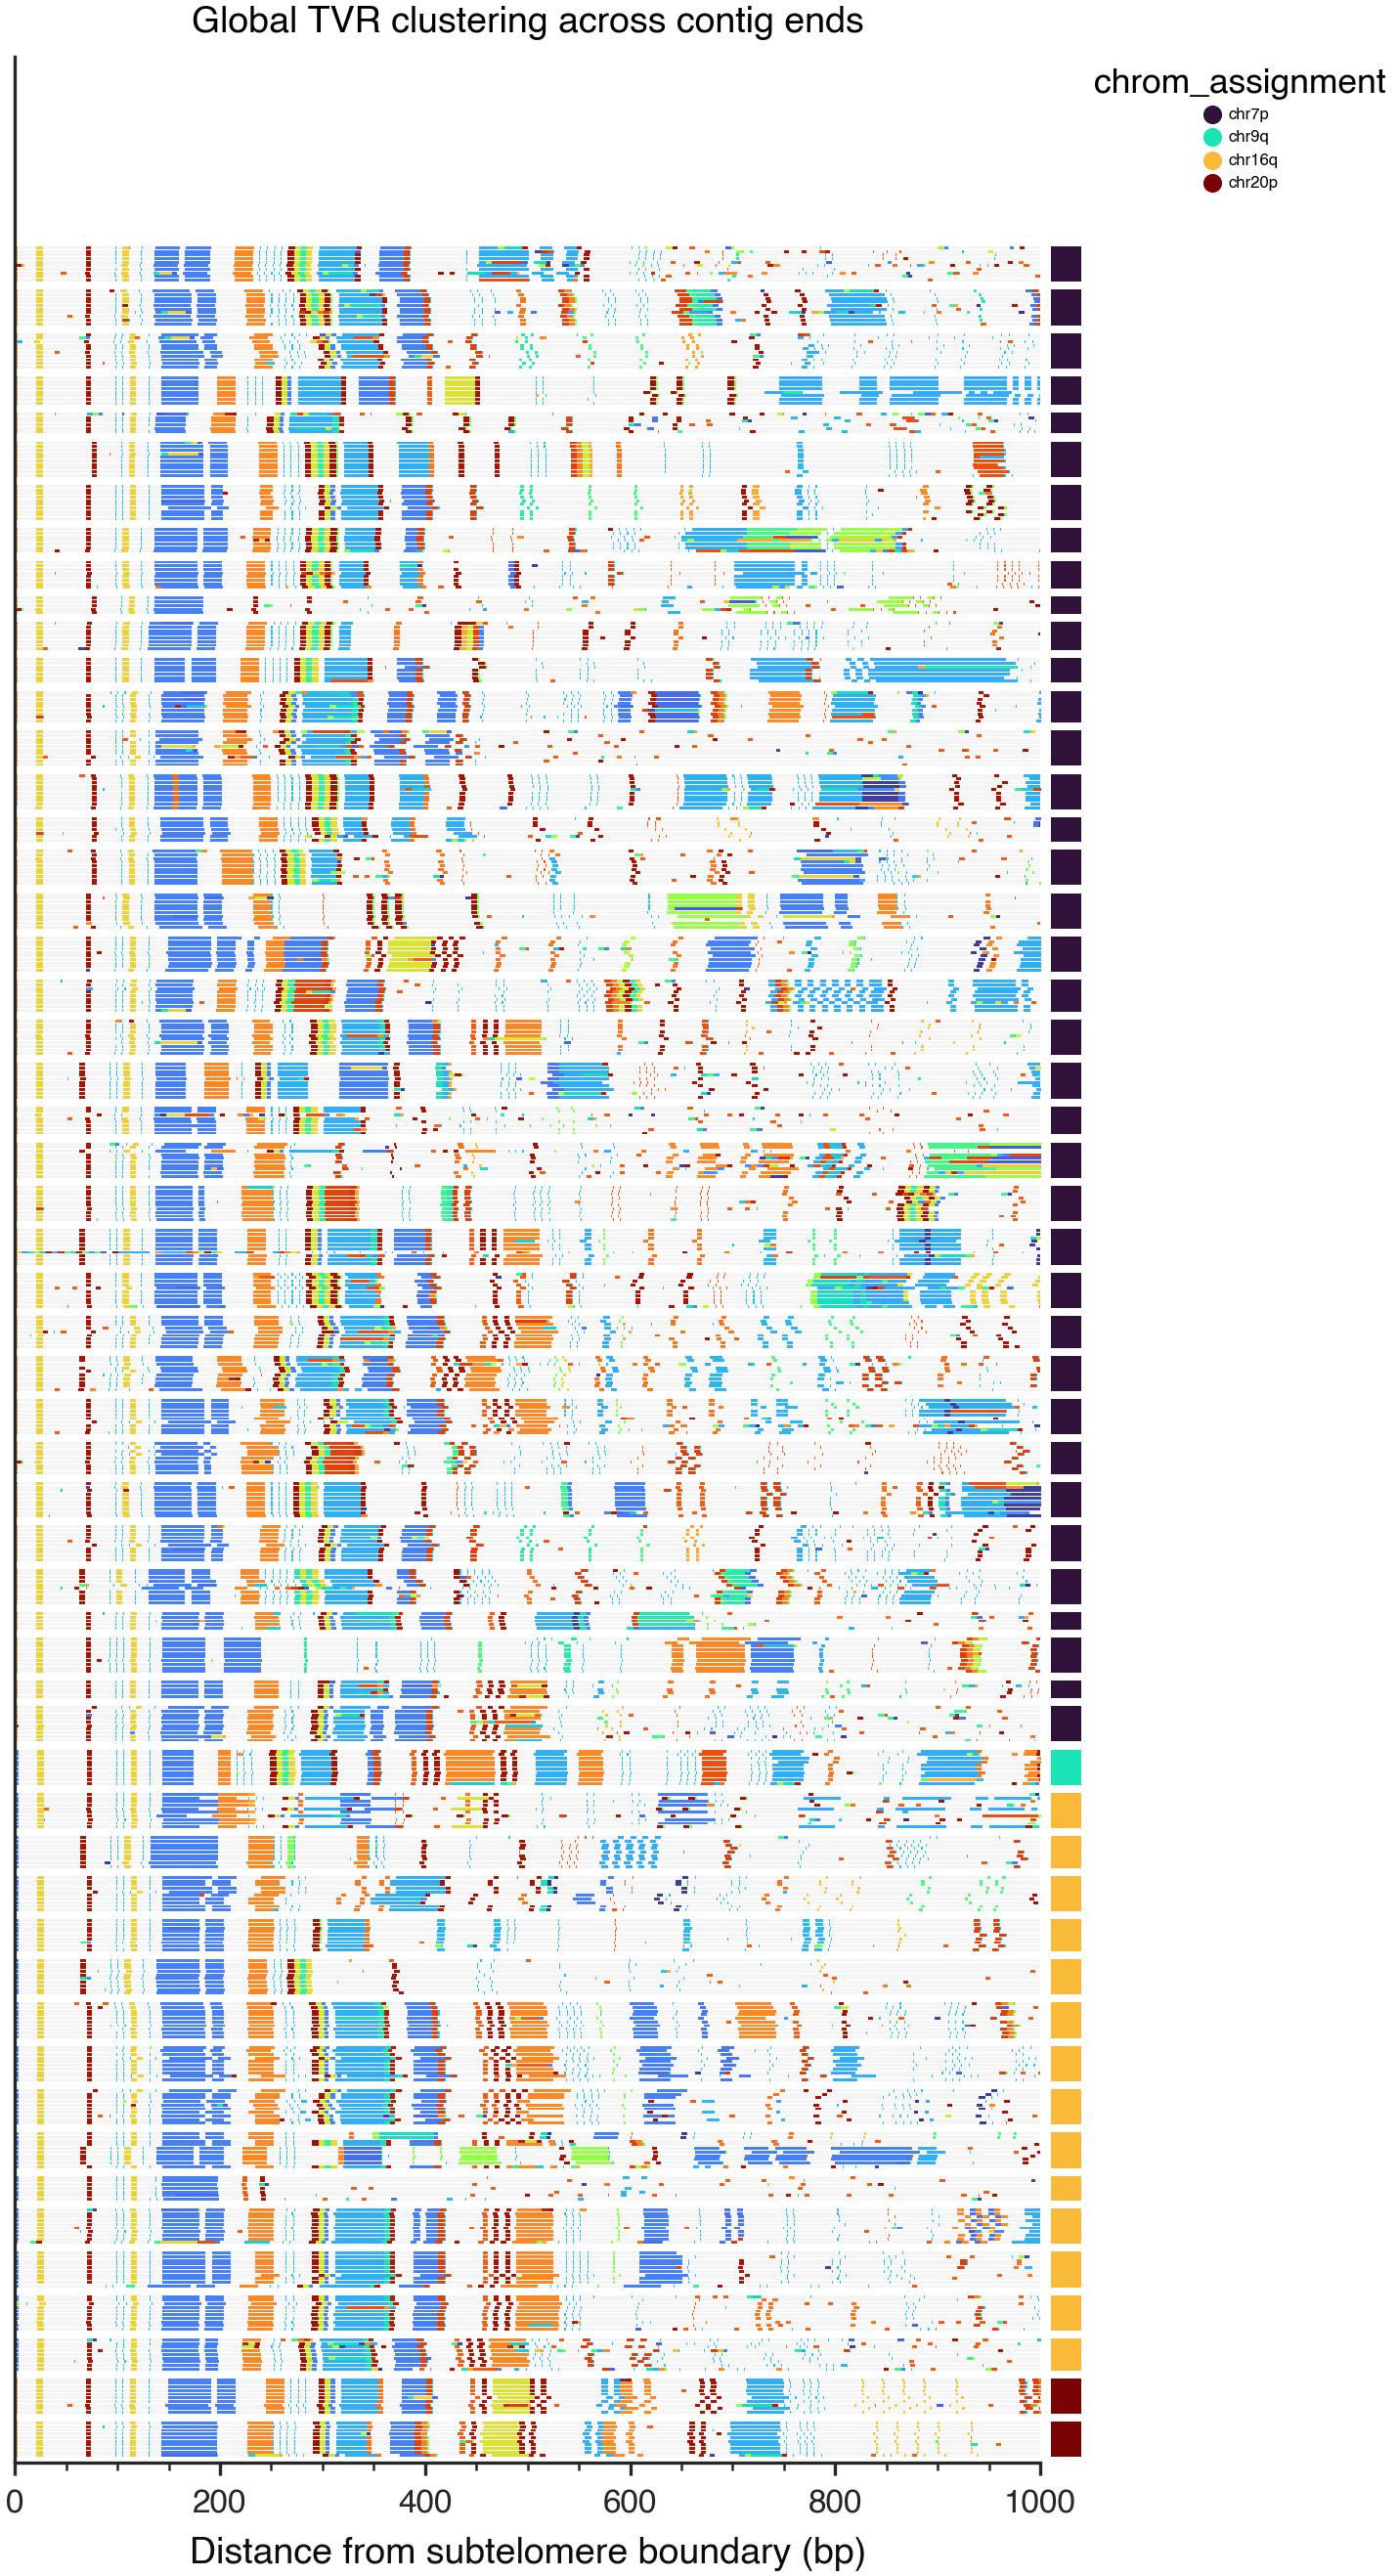

Plotting cluster 2209 (n=52, mean_sim=0.787) -> None
MultiIndex([('chr12p', 'HG00126#2#CM090130.1', 'HG00126_2'),
            ('chr12p', 'HG00128#2#CM090101.1', 'HG00128_2'),
            ('chr12p', 'HG00140#2#CM087142.1', 'HG00140_2'),
            ('chr12p', 'HG00253#1#CM094465.1', 'HG00253_1'),
            ('chr12p', 'HG00323#2#CM087336.1', 'HG00323_2'),
            ('chr12p', 'HG00642#2#CM086626.1', 'HG00642_2'),
            ('chr12p', 'HG00735#2#CM087893.1', 'HG00735_2'),
            ('chr12p', 'HG01258#1#CM088117.1', 'HG01258_1'),
            ('chr12p', 'HG01784#2#CM087603.1', 'HG01784_2'),
            ('chr12p', 'HG01928#1#CM088994.1', 'HG01928_1'),
            ('chr12p', 'HG01934#1#CM088846.1', 'HG01934_1'),
            ('chr12p', 'HG02300#1#CM086440.1', 'HG02300_1'),
            ('chr12p', 'HG03239#2#CM088767.1', 'HG03239_2'),
            ('chr12p', 'HG03927#1#CM086640.1', 'HG03927_1'),
            ('chr20q', 'HG00126#2#CM090134.1', 'HG00126_2'),
            ('chr20q', 'HG00232#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:02<00:00, 22.49it/s]


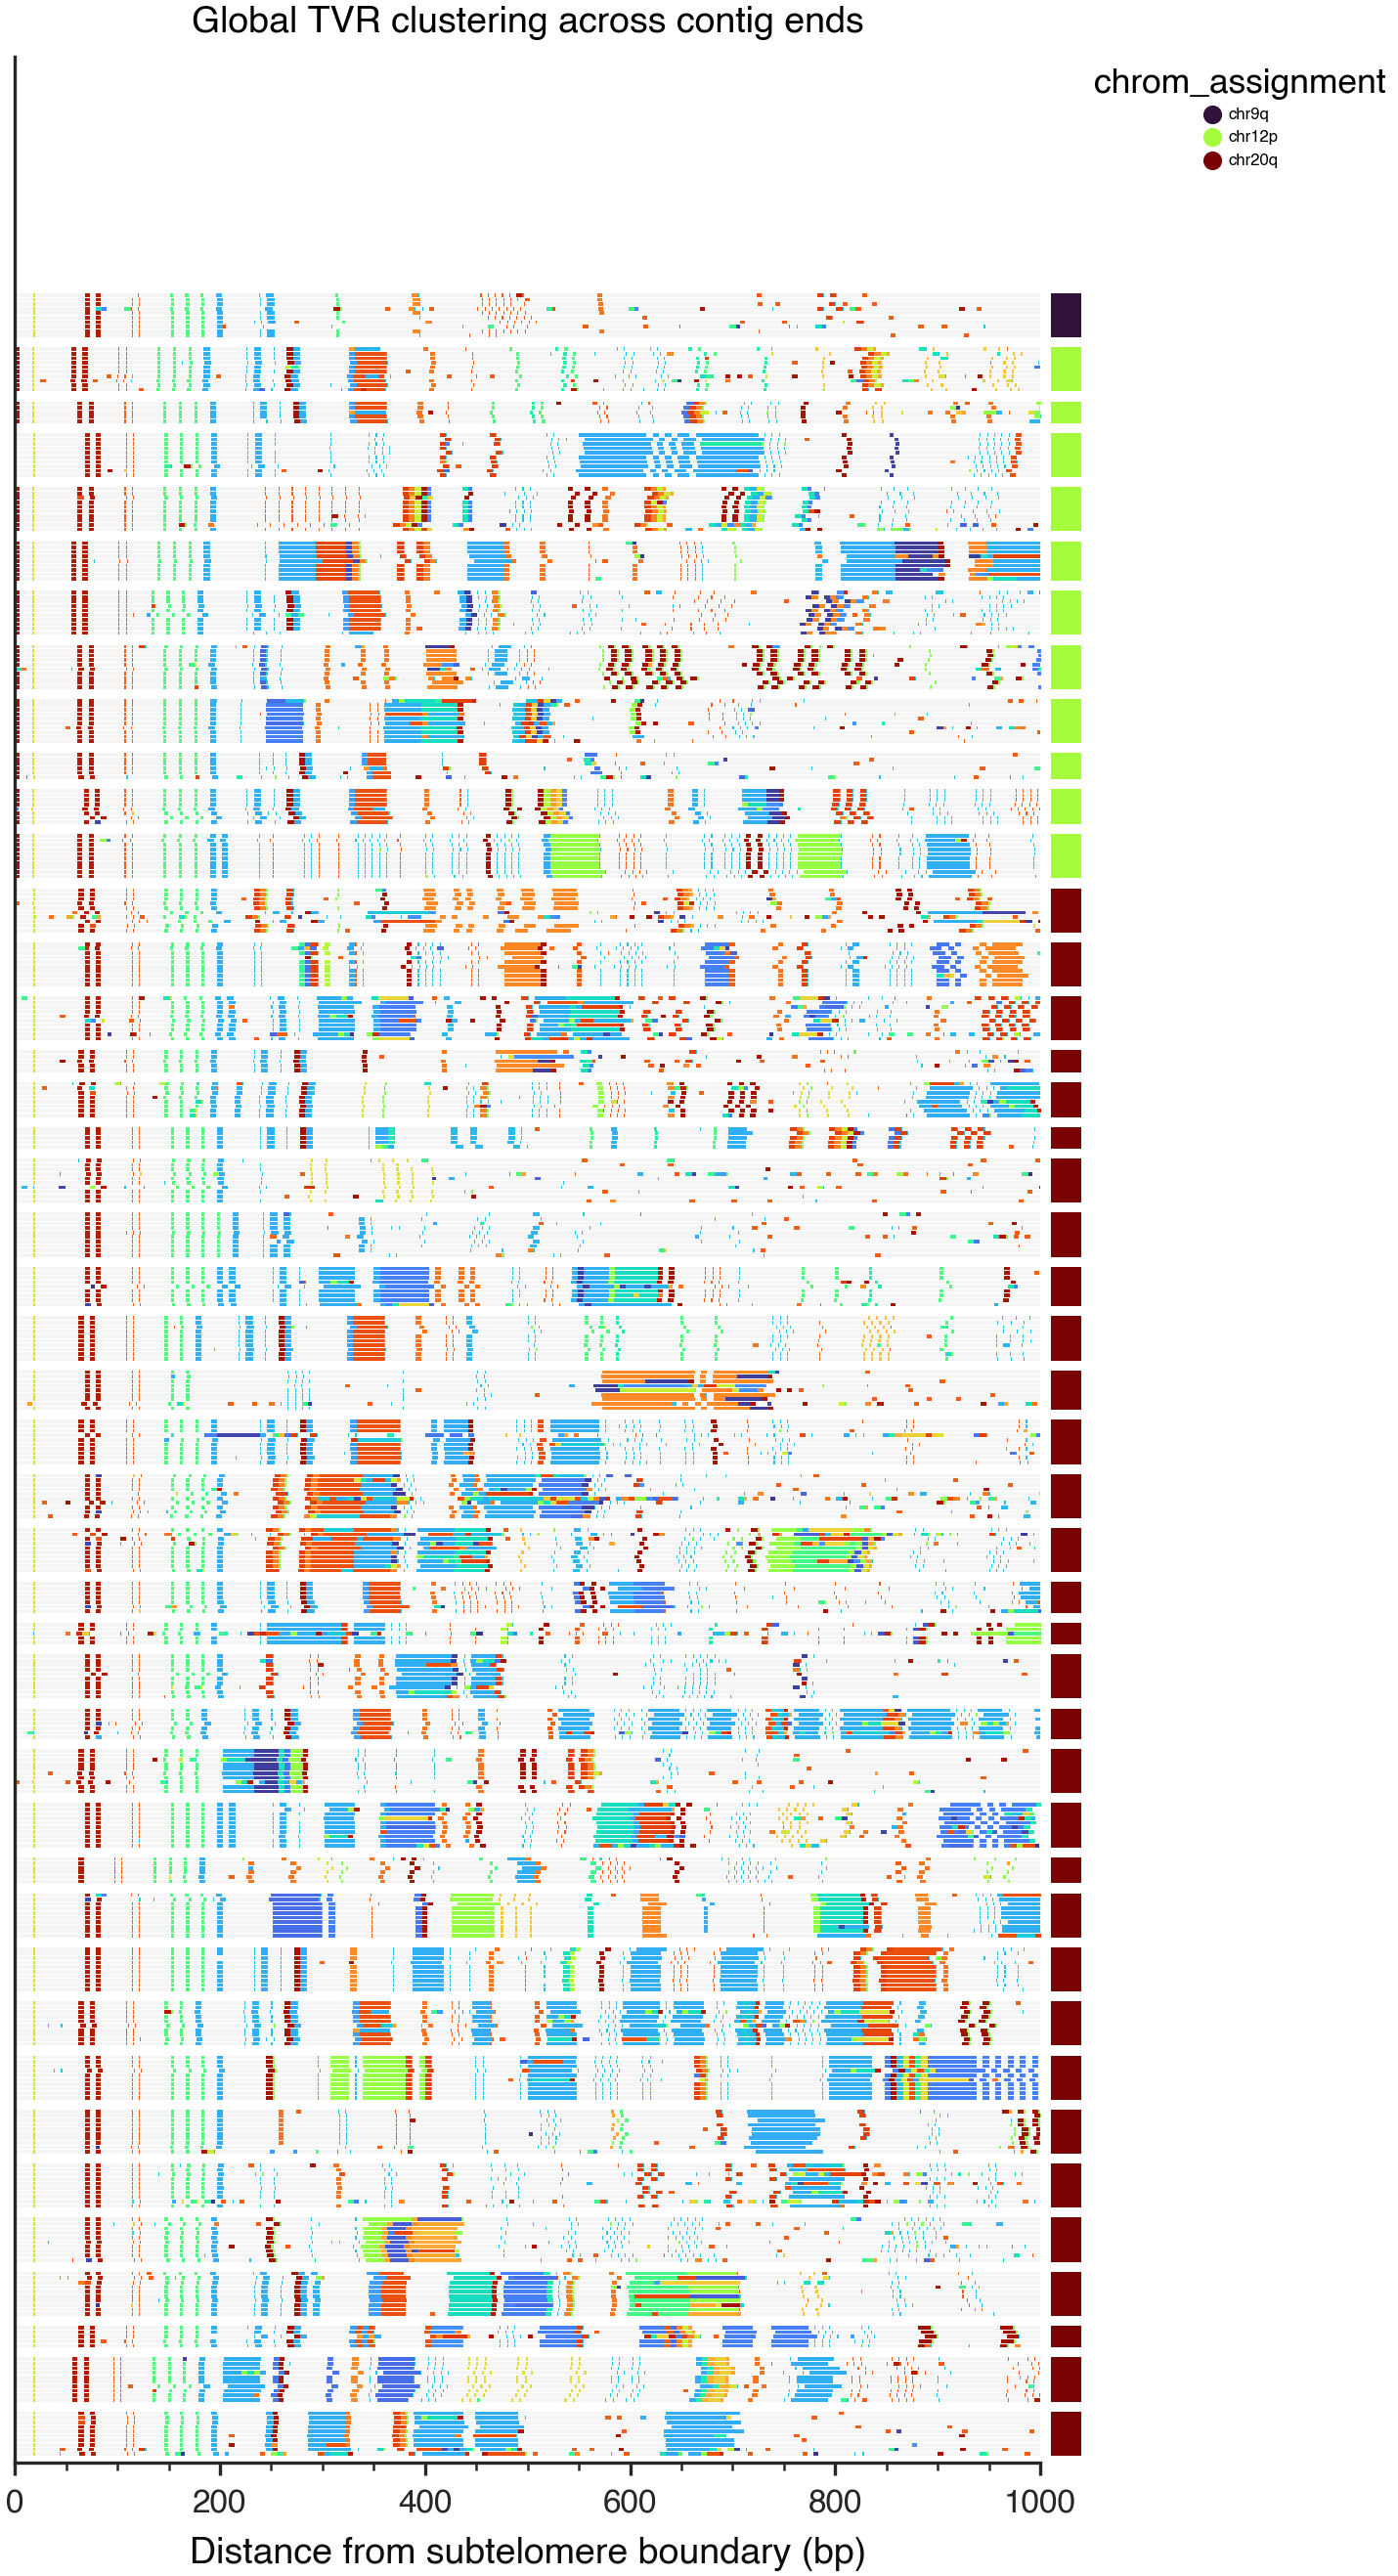

Plotting cluster 2655 (n=73, mean_sim=0.794) -> None
MultiIndex([('chr11p', 'HG03470#2#CM091875.1', 'HG03470_2'),
            ('chr15q', 'HG00321#1#CM089548.1', 'HG00321_1'),
            ('chr15q', 'HG00642#2#CM086629.1', 'HG00642_2'),
            ('chr15q', 'HG01940#1#CM088638.1', 'HG01940_1'),
            ('chr15q', 'HG02074#1#CM088276.1', 'HG02074_1'),
            ('chr15q', 'HG02155#1#CM091918.1', 'HG02155_1'),
            ('chr15q', 'HG02165#1#CM087450.1', 'HG02165_1'),
            ('chr15q', 'HG02922#1#CM087005.1', 'HG02922_1'),
            ('chr15q', 'NA18570#1#CM087667.1', 'NA18570_1'),
            ('chr15q', 'NA18570#2#CM087685.1', 'NA18570_2'),
            ('chr16p', 'HG02486#1#CM088201.1', 'HG02486_1'),
            ('chr16p', 'HG03209#1#CM087221.1', 'HG03209_1'),
            ('chr16q', 'HG01167#1#CM094534.1', 'HG01167_1'),
            ('chr16q', 'HG01891#2#CM088212.1', 'HG01891_2'),
            ('chr16q', 'HG01960#1#CM088652.1', 'HG01960_1'),
            ('chr16q', 'HG02486#

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:03<00:00, 18.68it/s]


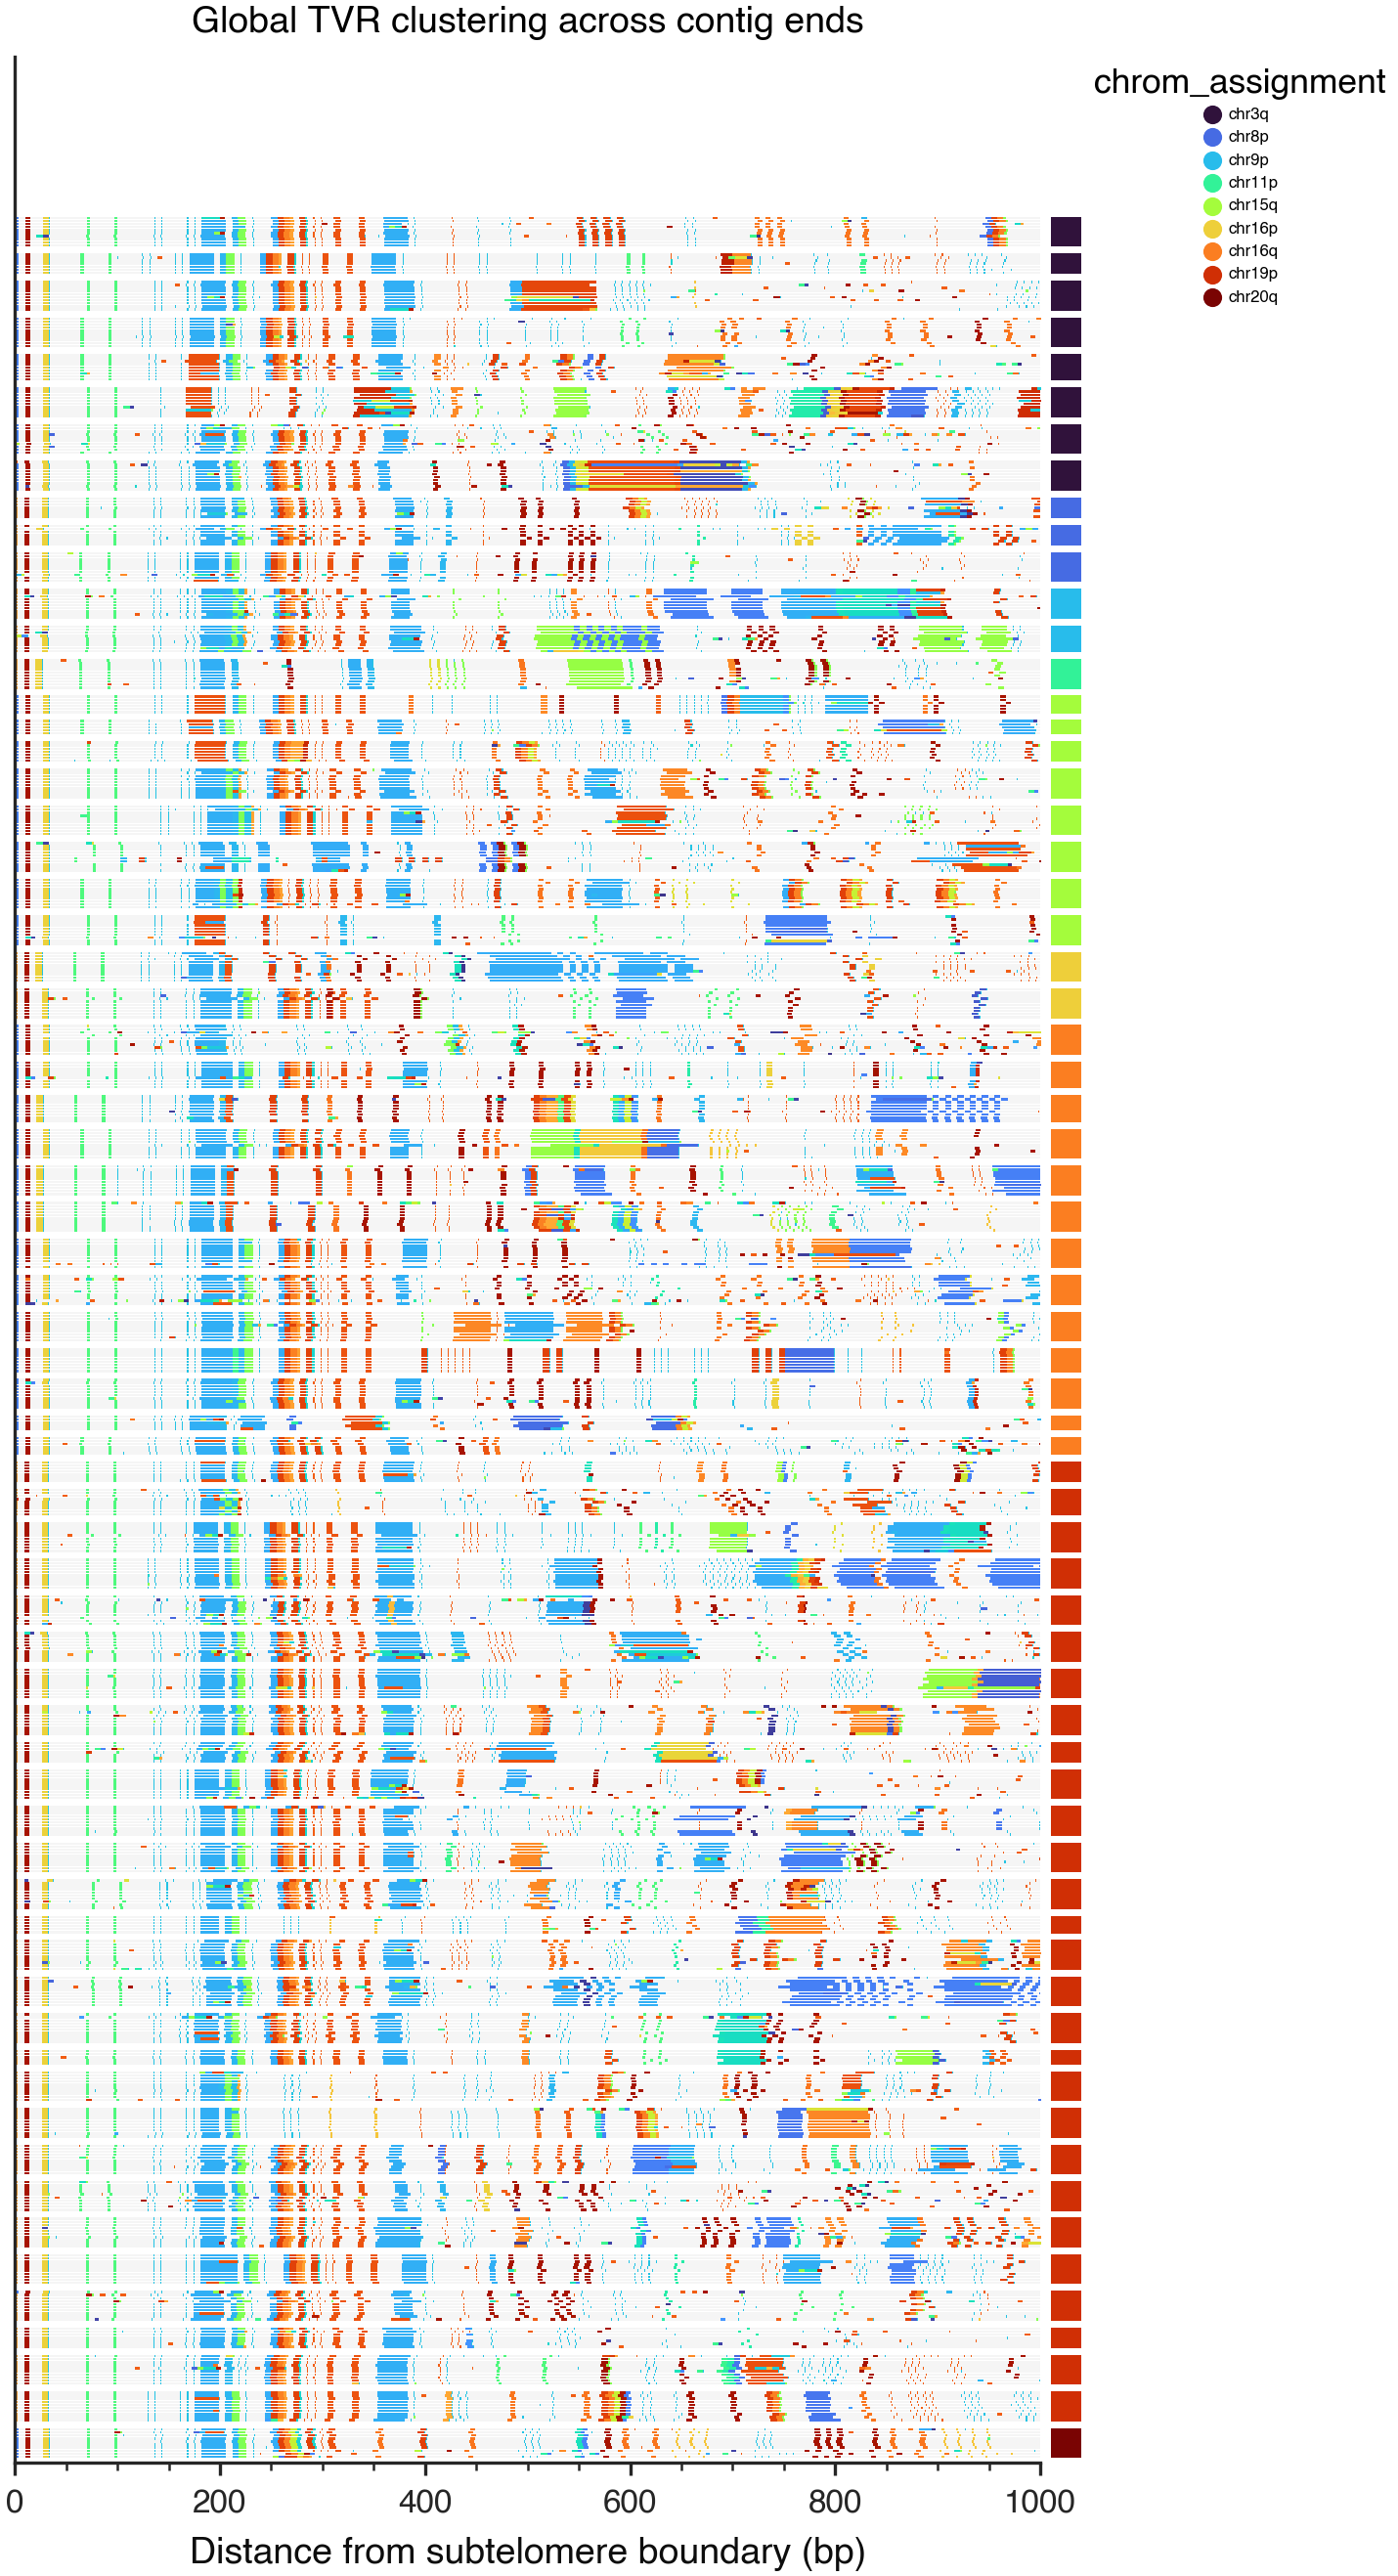

Plotting cluster 3486 (n=58, mean_sim=0.742) -> None
MultiIndex([('chr4p', 'HG00133#1#CM090048.1', 'HG00133_1'),
            ('chr4p', 'HG00438#1#CM089170.1', 'HG00438_1'),
            ('chr4p', 'HG00438#2#CM089189.1', 'HG00438_2'),
            ('chr4p', 'HG00609#1#CM086349.1', 'HG00609_1'),
            ('chr4p', 'HG00609#2#CM086359.1', 'HG00609_2'),
            ('chr4p', 'HG00621#1#CM087849.1', 'HG00621_1'),
            ('chr4p', 'HG00639#1#CM088538.1', 'HG00639_1'),
            ('chr4p', 'HG00642#2#CM086620.1', 'HG00642_2'),
            ('chr4p', 'HG00706#2#CM100058.1', 'HG00706_2'),
            ('chr4p', 'HG00735#2#CM087886.1', 'HG00735_2'),
            ('chr4p', 'HG01071#2#CM089130.1', 'HG01071_2'),
            ('chr4p', 'HG01175#2#CM087938.1', 'HG01175_2'),
            ('chr4p', 'HG01258#1#CM088111.1', 'HG01258_1'),
            ('chr4p', 'HG01346#2#CM086599.1', 'HG01346_2'),
            ('chr4p', 'HG01361#1#CM089022.1', 'HG01361_1'),
            ('chr4p', 'HG01433#2#CM086509.1', '

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58/58 [00:02<00:00, 21.67it/s]


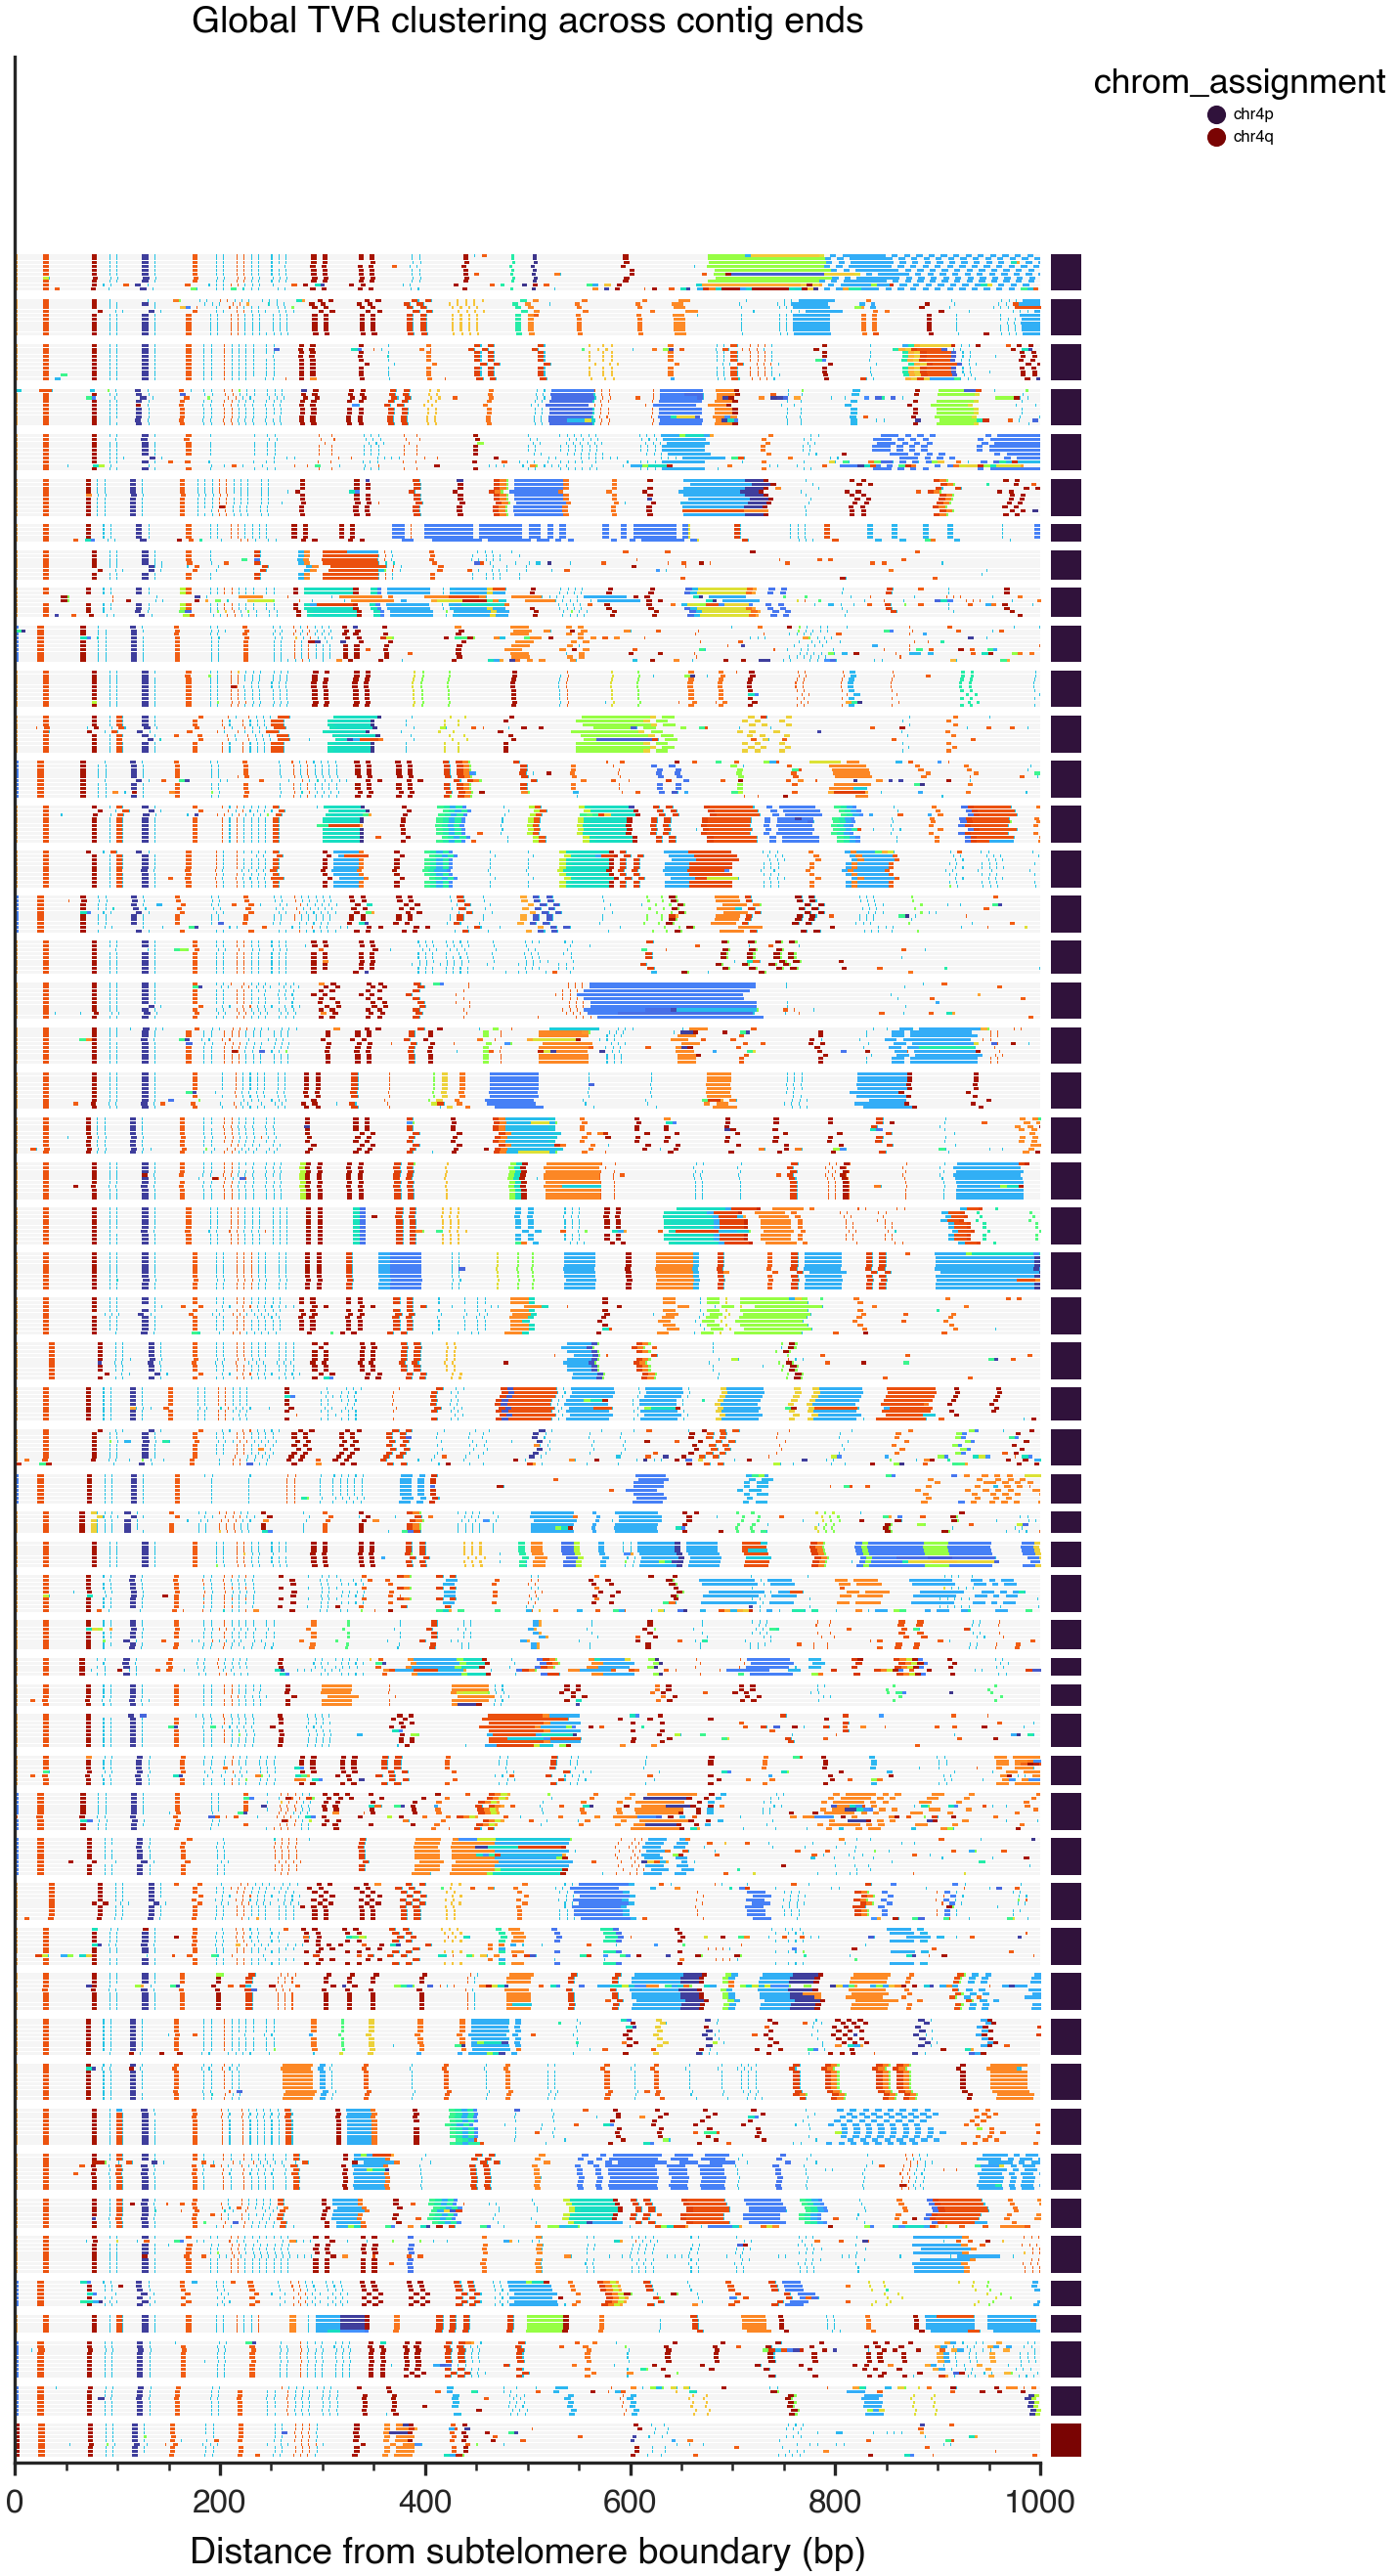

Plotting cluster 3680 (n=74, mean_sim=0.757) -> None
MultiIndex([('chr2q', 'HG03017#1#CM088909.1', 'HG03017_1'),
            ('chr2q', 'HG03816#1#CM100025.1', 'HG03816_1'),
            ('chr2q', 'NA20870#2#CM089709.1', 'NA20870_2'),
            ('chr5q', 'HG00097#1#CM094063.1', 'HG00097_1'),
            ('chr5q', 'HG00099#2#CM087360.1', 'HG00099_2'),
            ('chr5q', 'HG00133#2#CM090064.1', 'HG00133_2'),
            ('chr5q', 'HG00235#1#CM094372.1', 'HG00235_1'),
            ('chr5q', 'HG00320#2#CM089964.1', 'HG00320_2'),
            ('chr5q', 'HG00323#1#CM087305.1', 'HG00323_1'),
            ('chr5q', 'HG00344#2#CM094515.1', 'HG00344_2'),
            ('chr5q', 'HG00350#1#CM094471.1', 'HG00350_1'),
            ('chr5q', 'HG00408#2#CM085968.1', 'HG00408_2'),
            ('chr5q', 'HG00438#1#CM089171.1', 'HG00438_1'),
            ('chr5q', 'HG00544#1#CM089372.1', 'HG00544_1'),
            ('chr5q', 'HG00621#1#CM087850.1', 'HG00621_1'),
            ('chr5q', 'HG00621#2#CM087864.1', '

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74/74 [00:03<00:00, 23.31it/s]


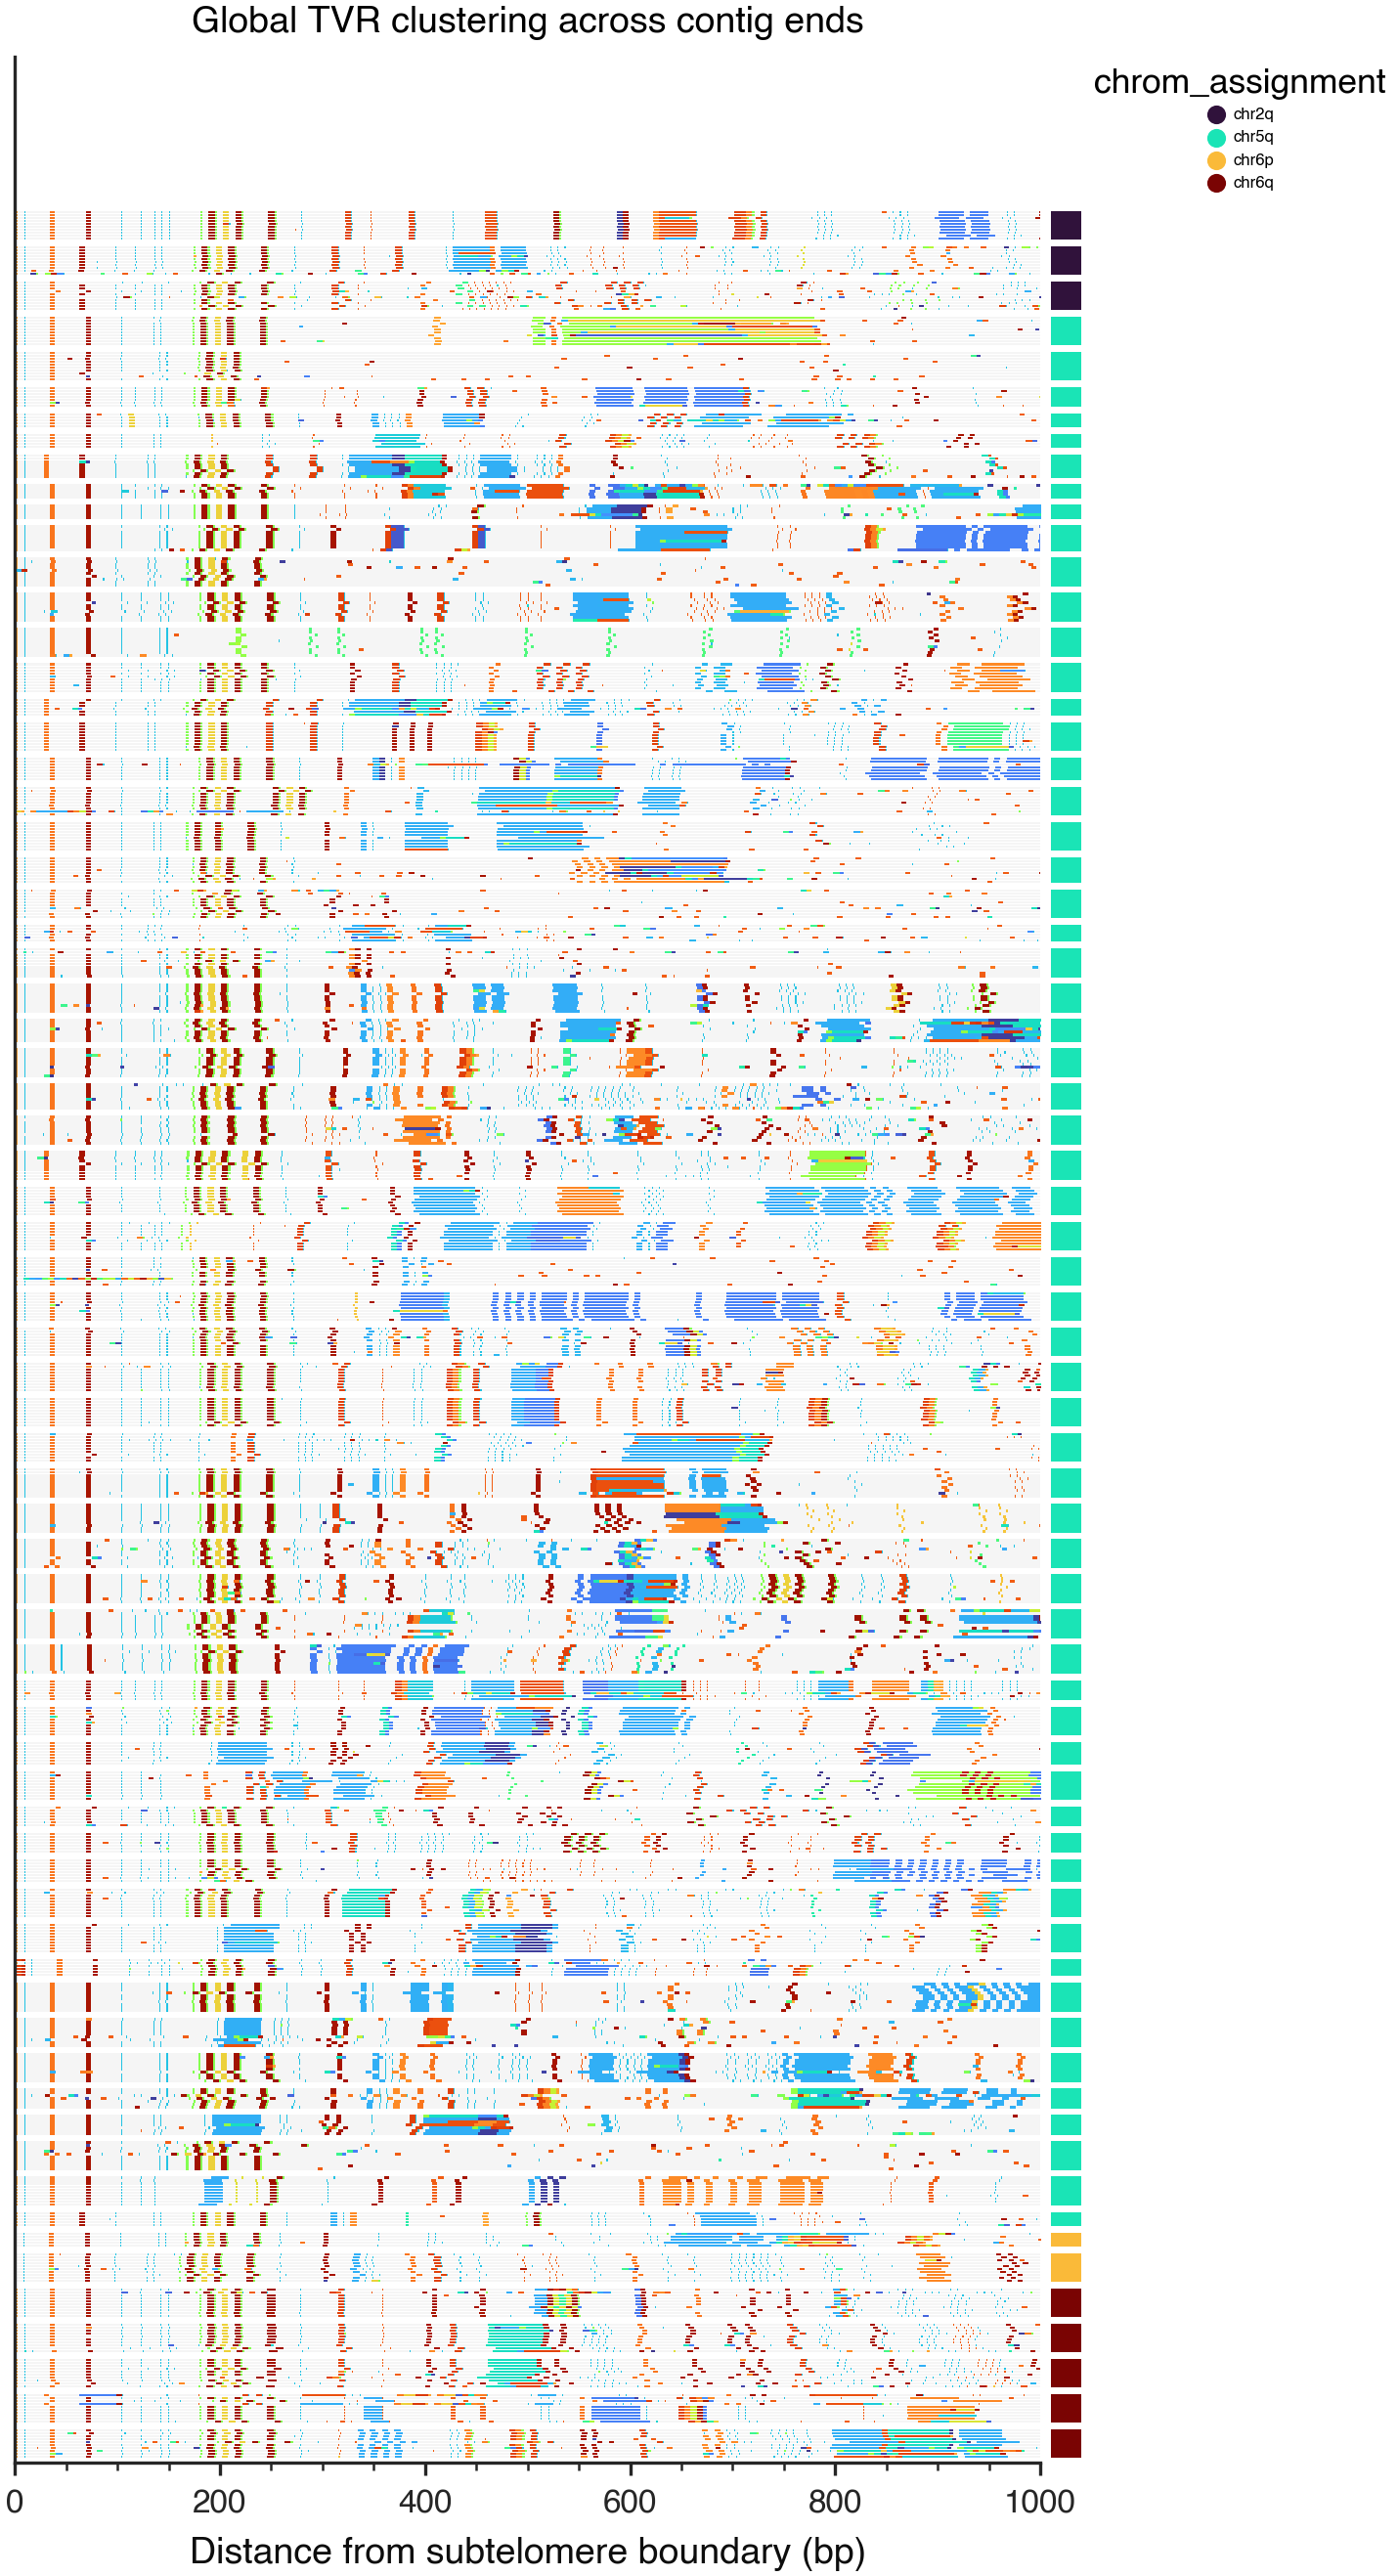

In [28]:
# supplement figures plot 10 mols

plot_significant_tvr_clusters(
    big_tsv=hprc_tsv_total_filtered,
    linkage_matrix=linkage_matrix,
    labels=labels,
    similarity_matrix=M,
    sim_threshold=0.7,
    min_contigs=50,
    dist_bp=1000,
    figsize=(5, 9),
    cmgr=cmgr,
    min_reads_per_group=5,
    min_tvr_size=1,
    max_tvr_size=300,
    flip=True,
    max_mols_per_group=10,
    out_prefix=None   
)

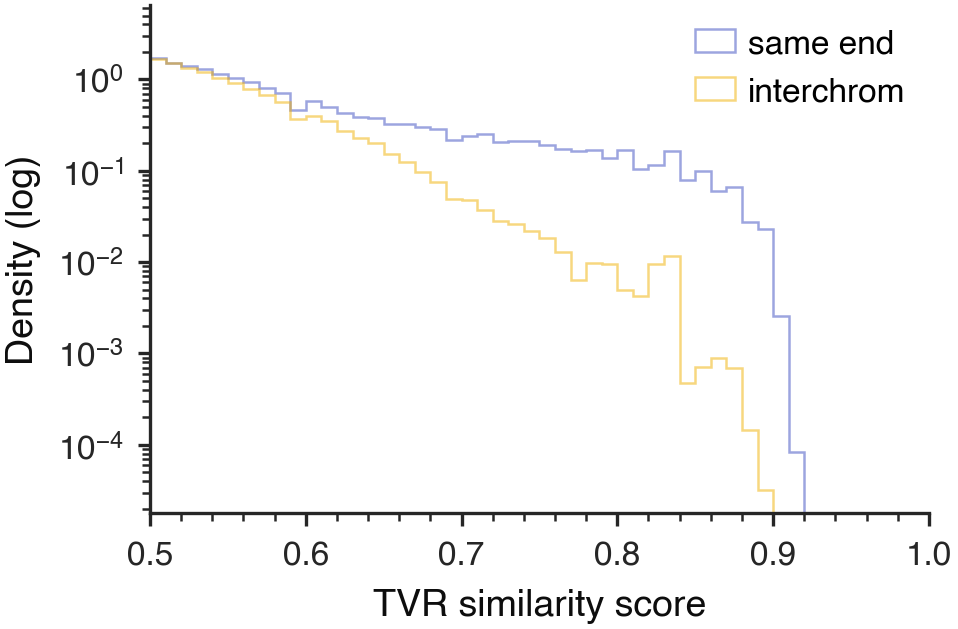

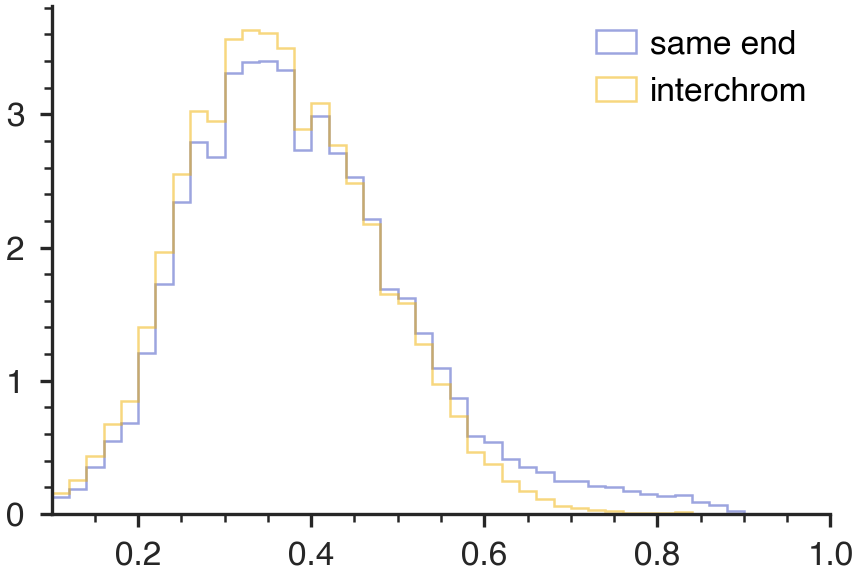

In [29]:
plt.hist(similarity_df.sim_t200[similarity_df.assignment_i==similarity_df.assignment_j],bins=100,alpha=0.5,
         density=True,cumulative=False,range=(0,1),histtype='step',log=True,label='same end')

plt.hist(similarity_df.sim_t200[similarity_df.assignment_i!=similarity_df.assignment_j],bins=100,alpha=0.5,
         density=True,cumulative=False,range=(0,1),histtype='step',log=True,label = 'interchrom')

plt.legend(frameon=False)
plt.xlim(0.5,1)
plt.ylabel('Density (log)')
plt.xlabel('TVR similarity score')
plt.show()

plt.hist(similarity_df.sim_t200[similarity_df.assignment_i==similarity_df.assignment_j],bins=50,alpha=0.5,
         density=True,cumulative=False,range=(0,1),histtype='step',log=False,label='same end')

plt.hist(similarity_df.sim_t200[similarity_df.assignment_i!=similarity_df.assignment_j],bins=50,alpha=0.5,
         density=True,cumulative=False,range=(0,1),histtype='step',log=False,label = 'interchrom')

plt.legend(frameon=False)
plt.xlim(0.1,1)
plt.show()

In [30]:
# quantify inter vs intra chromosomal comparisons


non_same = similarity_df.sim_t200[similarity_df.assignment_i!=similarity_df.assignment_j]
same     = similarity_df.sim_t200[similarity_df.assignment_i==similarity_df.assignment_j]

print(len(same),len(non_same))


print('percent > 0.8 similarity in same chrom end:', 100*sum(same > 0.8) / len(same))
print('percent > 0.8 similarity in different chrom end:',100*sum(non_same > 0.8) / len(non_same))

print(f'decrease : {100 * (1 - (sum(non_same > 0.8) / len(non_same))/(sum(same > 0.8) / len(same)))}%')


print(sum(same > 0.8))
print(sum(non_same > 0.8))
print(len(same))
print(len(non_same))

1203873 43925877
percent > 0.8 similarity in same chrom end: 0.8204353781503531
percent > 0.8 similarity in different chrom end: 0.03133005175969509
decrease : 96.1812895208971%
9877
13762
1203873
43925877


In [32]:
non_same_df = similarity_df[(similarity_df.assignment_i!=similarity_df.assignment_j) & (similarity_df.sim_t200 >=0.7)]
same_df     = similarity_df[similarity_df.assignment_i==similarity_df.assignment_j]


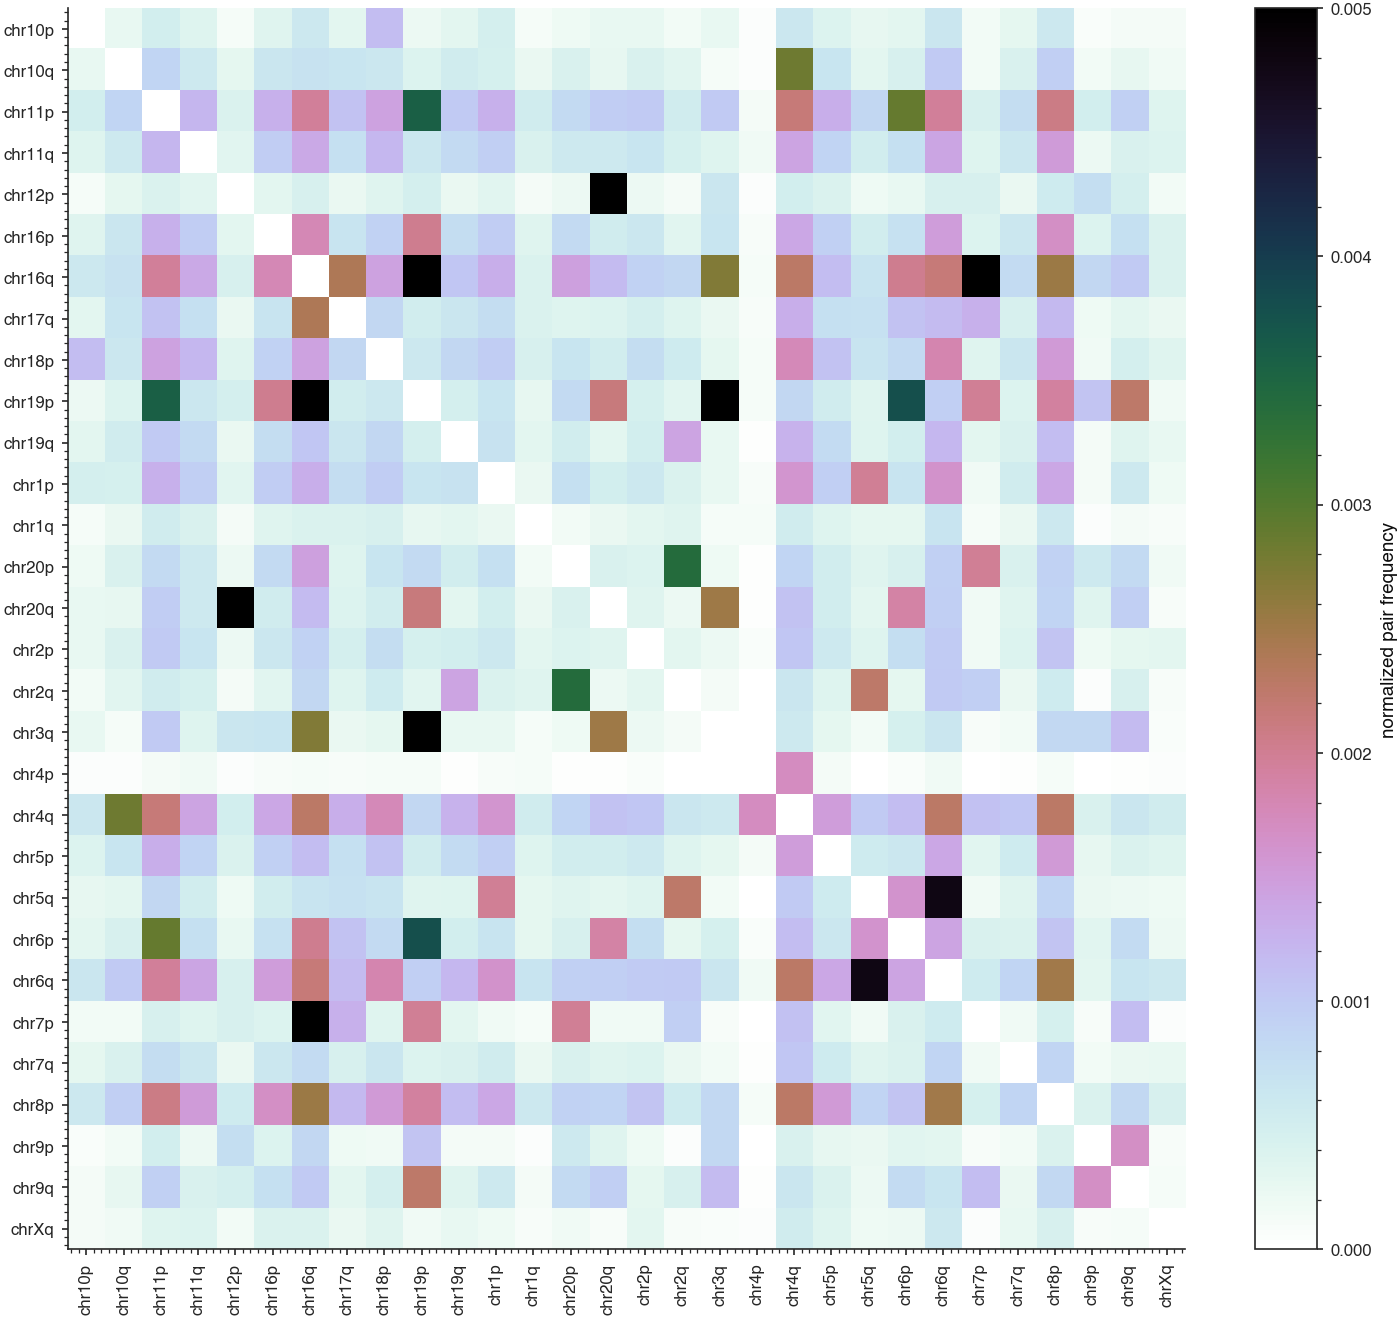

In [33]:
# counts in each column
ci = non_same_df["assignment_i"].value_counts()
cj = non_same_df["assignment_j"].value_counts()

# combined (times appears in i OR j)
counts_either = ci.add(cj, fill_value=0).astype(int).sort_values(ascending=False)
counts_either

pairs = pd.DataFrame({
    "a": non_same_df[["assignment_i","assignment_j"]].min(axis=1),
    "b": non_same_df[["assignment_i","assignment_j"]].max(axis=1),
})


contigs_per_end = (
    pd.concat([
        same_df[["assignment_i", "contig_i"]].rename(
            columns={"assignment_i": "assignment", "contig_i": "contig"}
        ),
        same_df[["assignment_j", "contig_j"]].rename(
            columns={"assignment_j": "assignment", "contig_j": "contig"}
        )
    ])
    .groupby("assignment")["contig"]
    .nunique()
)


pair_counts = (
    non_same_df
    .groupby(["assignment_i", "assignment_j"])
    .size()
    .reset_index(name="count")
)

pair_counts["Ni"] = pair_counts["assignment_i"].map(contigs_per_end)
pair_counts["Nj"] = pair_counts["assignment_j"].map(contigs_per_end)

pair_counts["normalized"] = (
    pair_counts["count"] /
    (pair_counts["Ni"] * pair_counts["Nj"])
)

# outlier arms 
drop_chroms = {"chrY", "chr13", "chr14", "chr15", "chr21", "chr22",'chr8q','chr12q','chrXp','chr17p','chr3p','chr18q'}

# keep only arms NOT belonging to those chromosomes
arms = sorted(
    a for a in set(non_same_df["assignment_i"]).union(non_same_df["assignment_j"])
    if not any(a.startswith(ch) for ch in drop_chroms)
)



mat_norm = (
    pair_counts
    .pivot(index="assignment_i", columns="assignment_j", values="normalized")
    .reindex(index=arms, columns=arms)
    .fillna(0)
)

M = mat_norm.copy().astype(float)

# symmetric
M = M + M.T

plt.figure(figsize=(10, 9), dpi=150)
plt.imshow(M.values, aspect="auto",cmap='cubehelix_r',vmin=0,vmax=.005)
plt.xticks(range(len(M.index)), M.index, rotation=90)
plt.yticks(range(len(M.index)), M.index)
plt.colorbar(label="normalized pair frequency")
plt.tight_layout()
plt.show()